# Benchmarking Neural Operator Architectures

*A controlled scaling study comparing four operator-learning architectures — FNO, DeepONet, iFOL, and a Transformer — at matched capacity tiers on the nonlinear heat-conduction problem.*

---

## 1. Motivation

Many architectures can learn solution operators, but published comparisons often differ in data, training budget, and model size at the same time, making it hard to attribute any advantage to the architecture itself. This chapter runs a **fair, controlled comparison**: identical data, optimizer, and epoch budget for every model, with only the architecture and its size varied.

## 2. The problem

All models learn the *steady-state* map from a spatially varying material profile $\alpha(x)$ to the temperature field $T(x)$ of the nonlinear conduction problem

$$\frac{d}{dx}\left(k(x,T)\,\frac{dT}{dx}\right)=0,\qquad k(x,T)=\alpha(x)\bigl(0.5+T^{2}\bigr),\qquad T(0)=1,\ T(1)=0 .$$

This is the **same rod as in the transient chapters (Part III)**, with the time derivative dropped: the steady field is exactly where the transient temperature ends up after a long time. The material $\alpha(x)$ is the only input — every initial state relaxes to the same steady field — so the operator to learn is $\alpha(x)\mapsto T(x)$.


**Ground truth.** All reference solutions come from `fem_ground_truth.py`, the one FEM module shared by every chapter of Parts II and III. The steady residual $K(T)\,T=0$ uses the same linear-element stiffness assembly as the transient solver and is solved with Newton–Raphson (exact Jacobian). It is solved **once** on a fine mesh ($N=511$ nodes, float64) for the 1000 material fields $\alpha(x)$ of the shared field pool — the very same fields the transient chapters use — and interpolated down to the $N=64$ training grid. The 1000 samples are split 800 / 100 / 100 (train / validation / held-out test) as in every other chapter. Out-of-distribution tests use 50 unseen material shapes (*Layered*, *Inclusion*, *Sawtooth*, *HF-Rand*; same $\alpha$ range as training, so novel in shape only), evaluated on six grids $N=64$–$256$ against the same fine solve. Full details: [The Benchmark Problem](benchmark_problem.ipynb).


## 3. The four architectures

- **FNO** — Fourier Neural Operator; global spectral convolutions in the frequency domain.
- **DeepONet** — a *branch* network encodes the input function and a *trunk* network encodes the query location; their inner product gives the output.
- **iFOL** — an implicit / physics-motivated operator variant with a small set of learnable frequency parameters ($\omega$).
- **Transformer** — self-attention over the spatial grid, treating nodes as tokens.

## 4. Fair-comparison protocol

Each architecture is instantiated at three **capacity tiers** — small, medium, large — by scaling width and depth. Every one of the resulting models is trained on the same 800 samples with the same AdamW settings for the same number of epochs, and scored on the same 100 held-out test samples.

<div align="center">

<br><em style="color:#475569;font-size:0.9em">Figure 1. The experimental grid: every (architecture, capacity tier) pair is trained under identical conditions and scored on the same metrics.</em>
</div>

## 5. Metrics recorded

For every (architecture, tier) cell we log: **in-distribution accuracy** (relative $L^2$ error vs. FEM on held-out samples), **out-of-distribution accuracy** (50 unseen material shapes evaluated on six grids up to $N=256$ — a super-resolution test), **parameter count**, **training and inference time**, and the full **convergence history**.

## 6. How to read the figures that follow

- **In-distribution predictions** overlay each model on the FEM ground truth for several samples, with a companion pointwise-error panel.
- **Out-of-distribution predictions** repeat this on unseen material shapes (layered, inclusion, sawtooth, high-frequency random) at resolutions up to four times the training grid.
- **Error-distribution box plots** summarize accuracy across train / held-out test / OOD for every model and tier at a glance.
- **Convergence curves** and **timing plots** report optimization behaviour and computational cost.

Together these separate three questions that are usually tangled: which architecture is most *accurate*, which *generalizes* best out of distribution, and which is most *efficient*.

## 7. Training the twelve models

Every (architecture, tier) pair is trained with the weighted-residual loss for 3000 steps, with batches of 32 and AdamW with a cosine-decayed learning rate. The cell prints, for each model, its configuration, parameter count, training time, relative $L^2$ error on the held-out test set, and mean relative $L^2$ error over the out-of-distribution evaluations, followed by a summary table. The next cell selects the six out-of-distribution scenarios shown in the prediction plots.

In [1]:
"""
Fair-comparison scaling study + rich presentation plots.
Small / medium / large × {FNO, DeepONet, iFOL, Transformer}.

Reports: val L2, params, runtime, OOD L2.
Plots:
  1. Convergence curves per size tier
  2. Scaling curves (Val L2, OOD vs params)
  3. L2 heatmaps (size × model)
  4. In-distribution predictions (large tier, 5 samples)
  5. OOD predictions (large tier, 6 scenarios)
  6. OOD per-scenario bars across all 3 tiers
"""
import jax
import jax.numpy as jnp
import optax
import time
import jax.tree_util as tree_util
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. SHARED CONFIG + GRID
# ==========================================
N_NODES = 64
N_ELEM = N_NODES - 1
from fem_ground_truth import (get_steady_reference, derive_steady_dataset, derive_steady_ood,
                              STEADY_ALPHA_MIN, STEADY_ALPHA_MAX)
K_MIN, K_MAX = STEADY_ALPHA_MIN, STEADY_ALPHA_MAX   # range of the material alpha(x) (iFOL input scaling)
EPOCHS = 3000
BATCH_SIZE = 32
LEARNING_RATE = 3e-3
N_SAMPLES = 1000
N_TRAIN = 800
TEST_START = 900       # 800/100/100 split shared with every chapter; models are scored on 900-999
STOP_GRAD_IN_K = False
LOG_EVERY = 100  # val loss log frequency

x_nodes_1d = jnp.linspace(0.0, 1.0, N_NODES)
x_nodes = x_nodes_1d.reshape(-1, 1)
GRID = x_nodes.flatten()
x_elem_1d = 0.5 * (x_nodes_1d[:-1] + x_nodes_1d[1:])
x_elem = x_elem_1d.reshape(-1, 1)

conn = jnp.stack([jnp.arange(N_ELEM), jnp.arange(1, N_NODES)], axis=1).astype(jnp.int32)
FREE_DOF = jnp.arange(1, N_NODES - 1)
row_idx = jnp.stack([conn[:, 0], conn[:, 0], conn[:, 1], conn[:, 1]], axis=1).reshape(-1)
col_idx = jnp.stack([conn[:, 0], conn[:, 1], conn[:, 0], conn[:, 1]], axis=1).reshape(-1)

# ==========================================
# 2. PHYSICS: weak residual used by the training loss (k = alpha(x)*(0.5+T^2)).
#    Ground truth comes from fem_ground_truth.py (Section 5), not from this chapter.
# ==========================================
GAUSS_XI = jnp.array([-1.0 / jnp.sqrt(3.0), 1.0 / jnp.sqrt(3.0)])
GAUSS_W = jnp.array([1.0, 1.0])

def element_B_J(xe):
    Le = xe[1] - xe[0]
    J = Le / 2.0
    B = jnp.array([-1.0 / Le, 1.0 / Le])
    N = jnp.stack([(1.0 - GAUSS_XI) / 2.0, (1.0 + GAUSS_XI) / 2.0], axis=1)
    return Le, J, B, N

def element_residual_only(xe, Te, k0e, stop_grad_in_k):
    _, J, B, N = element_B_J(xe)
    Tg = N @ Te
    gradT = B @ Te
    Tg_k = jax.lax.stop_gradient(Tg) if stop_grad_in_k else Tg
    k_eff_g = k0e * (0.5 + Tg_k**2)
    wJ = GAUSS_W * J
    s = jnp.sum(wJ * k_eff_g)
    return (s * gradT) * B

def assemble_residual(T, k_elem_base, stop_grad_in_k):
    xe = x_nodes_1d[conn]
    Te = T[conn]
    re = jax.vmap(lambda _xe, _Te, _k0: element_residual_only(_xe, _Te, _k0, stop_grad_in_k))(xe, Te, k_elem_base)
    R = jnp.zeros((N_NODES,))
    return R.at[conn].add(re)

# ==========================================
# 3. ARCHITECTURE FACTORIES
# ==========================================
def make_fno(hidden, layers, modes):
    def init_fno(key):
        params = []
        keys = jax.random.split(key, layers + 2)
        in_ch = 2
        for i in range(layers):
            k1, k2 = jax.random.split(keys[i])
            scale = 1.0 / jnp.sqrt(in_ch)
            params.append({
                'w_fft_r': jax.random.normal(k1, (modes, in_ch, hidden)) * scale,
                'w_fft_i': jax.random.normal(k1, (modes, in_ch, hidden)) * scale,
                'w_loc': jax.random.normal(k2, (in_ch, hidden)) * scale,
                'b_loc': jnp.zeros(hidden)
            })
            in_ch = hidden
        scale = 1.0 / jnp.sqrt(hidden)
        params.append({'w_out': jax.random.normal(keys[-2], (hidden, 1)) * scale, 'b_out': jnp.zeros(1)})
        params.append({'w_skip': jax.random.normal(keys[-1], (2, 1)) * scale})
        return params

    def predict_fno(params, k_elem, grid_1d, x_norm=None):
        grid_col = grid_1d.reshape(-1, 1)
        k_nodes = jnp.concatenate([k_elem[:1], 0.5*(k_elem[:-1]+k_elem[1:]), k_elem[-1:]])
        if k_nodes.shape[0] != grid_col.shape[0]:
            k_nodes = jnp.interp(grid_1d, jnp.linspace(0, 1, k_nodes.shape[0]), k_nodes)
        h = h_in = jnp.concatenate([grid_col, k_nodes.reshape(-1, 1)], axis=1)
        for i in range(layers):
            p = params[i]
            x_fft = jnp.fft.rfft(h, axis=0)
            mds = min(modes, x_fft.shape[0])
            w_cpx = p['w_fft_r'][:mds] + 1j * p['w_fft_i'][:mds]
            x_fft_out = jnp.einsum('mi,mio->mo', x_fft[:mds], w_cpx)
            padded = jnp.zeros((x_fft.shape[0], hidden), dtype=x_fft_out.dtype).at[:mds].set(x_fft_out)
            h = jax.nn.gelu(jnp.fft.irfft(padded, n=h.shape[0], axis=0) + jnp.dot(h, p['w_loc']) + p['b_loc'])
        T_nn = jnp.dot(h, params[-2]['w_out']) + params[-2]['b_out'] + jnp.dot(h_in, params[-1]['w_skip'])
        return ((1.0 - grid_col) + grid_col * (1.0 - grid_col) * T_nn).squeeze(-1)
    return init_fno, predict_fno


def make_deeponet(hidden, layers):
    def init_deeponet(key):
        params = {'branch': [], 'trunk': []}
        keys = jax.random.split(key, layers * 2 + 1)
        in_b, in_t = N_ELEM, 1
        for i in range(layers):
            params['branch'].append((jax.random.normal(keys[i], (in_b, hidden)) * jnp.sqrt(2.0/in_b), jnp.zeros(hidden)))
            params['trunk'].append((jax.random.normal(keys[i+layers], (in_t, hidden)) * jnp.sqrt(2.0/in_t), jnp.zeros(hidden)))
            in_b = in_t = hidden
        params['b_out'] = jnp.zeros(1)
        return params

    def predict_deeponet(params, k_elem, grid_1d, x_norm=None):
        grid_col = grid_1d.reshape(-1, 1)
        B = k_elem.flatten()
        if B.shape[0] != N_ELEM:
            B = jnp.interp(jnp.linspace(0, 1, N_ELEM), jnp.linspace(0, 1, B.shape[0]), B)
        T_net = grid_col
        for i in range(layers):
            B = jnp.dot(B, params['branch'][i][0]) + params['branch'][i][1]
            T_net = jnp.dot(T_net, params['trunk'][i][0]) + params['trunk'][i][1]
            if i < layers - 1:
                B, T_net = jax.nn.gelu(B), jax.nn.gelu(T_net)
        T_nn = jnp.dot(T_net, B)[:, None] + params['b_out']
        return ((1.0 - grid_col) + grid_col * (1.0 - grid_col) * T_nn).squeeze(-1)
    return init_deeponet, predict_deeponet


def make_ifol(hidden, layers, omega):
    K_LO, K_HI = K_MIN, K_MAX  # normalize k for controlled modulation variance

    def init_ifol(key):
        params = {'modulator': [], 'synthesizer': [], 'mod_gain': []}
        keys = jax.random.split(key, layers * 2 + 1)
        in_dim_syn = 1
        for i in range(layers):
            # modulator: normalized-k -> hidden shift, variance-controlled init
            W_m = jax.random.normal(keys[i], (N_ELEM, hidden)) / jnp.sqrt(N_ELEM)
            params['modulator'].append((W_m, jnp.zeros(hidden)))
            # learnable per-layer modulation strength, starts gentle
            params['mod_gain'].append(jnp.array(0.1))
            # standard SIREN synthesizer init (bound uses the *initial* omega)
            bd = 1.0 / in_dim_syn if i == 0 else jnp.sqrt(6.0 / in_dim_syn) / omega
            W_s = jax.random.uniform(keys[i + layers], (in_dim_syn, hidden), minval=-bd, maxval=bd)
            params['synthesizer'].append((W_s, jnp.zeros(hidden)))
            in_dim_syn = hidden
        params['out'] = (jax.random.normal(keys[-1], (hidden, 1)) / jnp.sqrt(hidden), jnp.zeros(1))
        # learnable per-layer frequency, initialized from config omega
        params['omega'] = jnp.full((layers,), float(omega))
        return params

    def predict_ifol(params, k_elem, grid_1d, x_norm=None):
        grid_col = grid_1d.reshape(-1, 1)
        k_flat = k_elem.flatten()
        if k_flat.shape[0] != N_ELEM:
            k_flat = jnp.interp(jnp.linspace(0, 1, N_ELEM),
                                jnp.linspace(0, 1, k_flat.shape[0]), k_flat)
        # map k -> ~[-1, 1] so the injected shift has O(1), width-stable variance
        k_n = 2.0 * (k_flat - K_LO) / (K_HI - K_LO) - 1.0
        H = grid_col
        for i in range(layers):
            W_m, b_m = params['modulator'][i]
            W_s, b_s = params['synthesizer'][i]
            g  = params['mod_gain'][i]
            om = params['omega'][i]
            shift = g * (jnp.dot(k_n, W_m) + b_m)
            H = jnp.dot(H, W_s) + b_s + shift
            if i < layers - 1:
                H = jnp.sin(om * H)
        W_out, b_out = params['out']
        T_nn = jnp.dot(H, W_out) + b_out
        return ((1.0 - grid_col) + grid_col * (1.0 - grid_col) * T_nn).squeeze(-1)
    return init_ifol, predict_ifol

def make_transformer(width, layers, heads, mlp_mult):
    assert width % heads == 0
    head_dim = width // heads

    def layer_norm(x, scale, bias, eps=1e-5):
        m = jnp.mean(x, axis=-1, keepdims=True)
        v = jnp.mean((x - m) ** 2, axis=-1, keepdims=True)
        return (x - m) / jnp.sqrt(v + eps) * scale + bias

    def mha(x, p_attn):
        n, d = x.shape
        qkv = x @ p_attn["W_qkv"] + p_attn["b_qkv"]
        q, k, v = jnp.split(qkv, 3, axis=-1)
        def sh(t): return t.reshape(n, heads, head_dim).transpose(1, 0, 2)
        qh, kh, vh = map(sh, (q, k, v))
        a = jax.nn.softmax(jnp.einsum("hnd,hmd->hnm", qh, kh) / jnp.sqrt(head_dim), axis=-1)
        out = jnp.einsum("hnm,hmd->hnd", a, vh).transpose(1, 0, 2).reshape(n, d)
        return out @ p_attn["W_o"] + p_attn["b_o"]

    def mlp_blk(x, p_mlp):
        return jax.nn.gelu(x @ p_mlp["W1"] + p_mlp["b1"]) @ p_mlp["W2"] + p_mlp["b2"]

    def block(x, p_blk):
        y = layer_norm(x, p_blk["ln1_scale"], p_blk["ln1_bias"])
        x = x + mha(y, p_blk["attn"])
        y = layer_norm(x, p_blk["ln2_scale"], p_blk["ln2_bias"])
        return x + mlp_blk(y, p_blk["mlp"])

    def init_transformer(key):
        def lin(k, d_in, d_out, s=None):
            if s is None: s = jnp.sqrt(1.0 / d_in)
            return jax.random.normal(k, (d_in, d_out)) * s, jnp.zeros((d_out,))
        keys = jax.random.split(key, 1 + 4*layers + 2)
        kk = 0
        W_in, b_in = lin(keys[kk], 2, width); kk += 1
        blocks = []
        for _ in range(layers):
            W_qkv, b_qkv = lin(keys[kk], width, 3*width); kk += 1
            W_o, b_o     = lin(keys[kk], width, width);   kk += 1
            W1, b1       = lin(keys[kk], width, mlp_mult*width); kk += 1
            W2, b2       = lin(keys[kk], mlp_mult*width, width); kk += 1
            blocks.append({
                "ln1_scale": jnp.ones((width,)), "ln1_bias": jnp.zeros((width,)),
                "attn": {"W_qkv": W_qkv, "b_qkv": b_qkv, "W_o": W_o, "b_o": b_o},
                "ln2_scale": jnp.ones((width,)), "ln2_bias": jnp.zeros((width,)),
                "mlp": {"W1": W1, "b1": b1, "W2": W2, "b2": b2},
            })
        W_ff, b_ff   = lin(keys[kk], width, width); kk += 1
        W_out, b_out = lin(keys[kk], width, 1, s=jnp.sqrt(1.0/width)); kk += 1
        return {"W_in": W_in, "b_in": b_in, "blocks": blocks,
                "W_ff": W_ff, "b_ff": b_ff, "W_out": W_out, "b_out": b_out}

    def predict_transformer(params, k_elem, grid_1d, x_norm=None):
        if x_norm is None:
            k_nodes = jnp.concatenate([k_elem[:1], (k_elem[:-1]+k_elem[1:])/2.0, k_elem[-1:]])
            if k_nodes.shape[0] != grid_1d.shape[0]:
                k_nodes = jnp.interp(grid_1d, jnp.linspace(0, 1, k_nodes.shape[0]), k_nodes)
            xn = jnp.stack([k_nodes, grid_1d], axis=-1)
        else:
            xn = x_norm
        x = jax.nn.gelu(xn @ params["W_in"] + params["b_in"])
        for l in range(layers):
            x = block(x, params["blocks"][l])
        x = jax.nn.gelu(x @ params["W_ff"] + params["b_ff"])
        res = (x @ params["W_out"] + params["b_out"]).squeeze(-1)
        return (1.0 - grid_1d) + grid_1d * (1.0 - grid_1d) * res
    return init_transformer, predict_transformer

# ==========================================
# 4. SIZE CONFIGS
# ==========================================
SIZE_CONFIGS = {
    "small": {
        "FNO":         dict(hidden=24, layers=2, modes=8),
        "DeepONet":    dict(hidden=40, layers=3),
        "iFOL":        dict(hidden=32, layers=4, omega=5.0),
        "Transformer": dict(width=24, layers=2, heads=4, mlp_mult=2),
    },
    "medium": {
        "FNO":         dict(hidden=48, layers=2, modes=8),
        "DeepONet":    dict(hidden=80, layers=4),
        "iFOL":        dict(hidden=96, layers=4, omega=5.0),
        "Transformer": dict(width=32, layers=4, heads=4, mlp_mult=4),
    },
    "large": {
        "FNO":         dict(hidden=64, layers=3, modes=12),
        "DeepONet":    dict(hidden=176, layers=4),
        "iFOL":        dict(hidden=224, layers=4, omega=3.0),
        "Transformer": dict(width=64, layers=4, heads=4, mlp_mult=4),
    },
}

FACTORIES = {
    "FNO": make_fno,
    "DeepONet": make_deeponet,
    "iFOL": make_ifol,
    "Transformer": make_transformer,
}

# ==========================================
# 5. DATA: the shared steady FEM reference (fem_ground_truth.py)
#    solved once on a fine N=511 mesh with Newton-Raphson, interpolated to N_NODES
# ==========================================
print("Loading the steady FEM reference (fem_ground_truth.py)...")
REF = get_steady_reference("checkpoints/steady_reference.npz", "checkpoints/field_pool.npz")
_d = derive_steady_dataset(REF, N_NODES)
alpha_nodes = jnp.asarray(_d["alpha"])
k_dataset_elem = 0.5 * (alpha_nodes[:, :-1] + alpha_nodes[:, 1:])     # element values (model input)
T_fem_dataset = jnp.asarray(_d["T"])

@jax.jit
def elem_to_nodes(k_e): return jnp.concatenate([k_e[:1], (k_e[:-1]+k_e[1:])/2.0, k_e[-1:]])
k_dataset_nodes = jax.vmap(elem_to_nodes)(k_dataset_elem)
grid_expanded = jnp.tile(GRID, (N_SAMPLES, 1))
X_raw = jnp.stack([k_dataset_nodes, grid_expanded], axis=-1)
x_mean = X_raw[:N_TRAIN].mean(axis=(0, 1))
x_std = X_raw[:N_TRAIN].std(axis=(0, 1)) + 1e-7
X_norm = (X_raw - x_mean) / x_std

# "val" below is the HELD-OUT TEST set (900-999): no early stopping is used in this chapter.
k_train_elem, k_val_elem = k_dataset_elem[:N_TRAIN], k_dataset_elem[TEST_START:]
X_train_norm, X_val_norm = X_norm[:N_TRAIN], X_norm[TEST_START:]
T_fem_val = T_fem_dataset[TEST_START:]

# ==========================================
# 6. OOD SCENARIOS: 50 unseen alpha shapes x 6 grids, same fine FEM reference
# ==========================================
OOD_RES_CHOICES = [64, 96, 128, 160, 192, 256]   # training grid is 64 -> the rest are super-res

def _ood_entry(o):
    k_prof = jnp.asarray(o["alpha"]); gl = jnp.linspace(0, 1, o["res"])
    return (o["label"], k_prof, gl, 0.5 * (k_prof[:-1] + k_prof[1:]), jnp.asarray(o["T"]))

OOD_GT = [_ood_entry(o) for res in OOD_RES_CHOICES for o in derive_steady_ood(REF, res)]
N_OOD = len(OOD_GT)

# ==========================================
# 7. TRAIN-EVAL LOOP
# ==========================================
def evaluate_val_l2(params, predict_fn, name):
    pred = (lambda p, k, x: predict_fn(p, k, GRID, x)) if name == "Transformer" \
           else (lambda p, k, x: predict_fn(p, k, GRID))
    preds = jax.vmap(pred, in_axes=(None, 0, 0))(params, k_val_elem, X_val_norm)
    return float(jnp.mean(jnp.linalg.norm(preds - T_fem_val, axis=1) /
                          (jnp.linalg.norm(T_fem_val, axis=1) + 1e-8)))

def evaluate_ood_l2(params, predict_fn, name):
    out = {}
    for title, k_prof, gl, k_elem_local, y_fem in OOD_GT:
        if name == "Transformer":
            x_norm_local = (jnp.stack([k_prof, gl], axis=-1) - x_mean) / x_std
            y_pred = predict_fn(params, k_elem_local, gl, x_norm_local)
        else:
            y_pred = predict_fn(params, k_elem_local, gl)
        out[title] = float(jnp.linalg.norm(y_fem - y_pred) / (jnp.linalg.norm(y_fem) + 1e-8))
    return out

def train_one(name, init_fn, predict_fn):
    k = jax.random.PRNGKey(0)
    params = init_fn(k)
    n_params = int(sum(x.size for x in tree_util.tree_leaves(params)))

    lr_sched = optax.cosine_decay_schedule(init_value=LEARNING_RATE, decay_steps=EPOCHS, alpha=0.01)
    optimizer = optax.chain(optax.clip_by_global_norm(1.0),
                            optax.adamw(learning_rate=lr_sched, weight_decay=1e-4))
    opt_state = optimizer.init(params)

    def loss_fn(p, k_base, x_feat):
        T_pred = predict_fn(p, k_base, GRID, x_feat) if name == "Transformer" else predict_fn(p, k_base, GRID)
        R = assemble_residual(T_pred, k_base, stop_grad_in_k=STOP_GRAD_IN_K)
        # Stop gradient on the physical residual formulation
        R_stopped = jax.lax.stop_gradient(R)
        
        # Weighted residual projection on the internal nodes
        # This matches jnp.sum(T[1:-1] * R[1:-1])
        return jnp.sum(T_pred[FREE_DOF] * R_stopped[FREE_DOF])

    @jax.jit
    def step(p, opt_s, b_k, b_x):
        loss_val, grads = jax.value_and_grad(lambda p_: jnp.mean(jax.vmap(loss_fn, in_axes=(None,0,0))(p_, b_k, b_x)))(p)
        updates, opt_s = optimizer.update(grads, opt_s, p)
        return optax.apply_updates(p, updates), opt_s, loss_val

    @jax.jit
    def val_loss_fn(p):
        return jnp.mean(jax.vmap(loss_fn, in_axes=(None, 0, 0))(p, k_val_elem, X_val_norm))

    history = {"step": [], "train_loss": [], "val_loss": []}
    t0 = time.time()
    for i in range(EPOCHS):
        idx = jax.random.randint(jax.random.PRNGKey(i), (BATCH_SIZE,), 0, N_TRAIN)
        params, opt_state, tloss = step(params, opt_state, k_train_elem[idx], X_train_norm[idx])
        if i % LOG_EVERY == 0:
            vloss = float(val_loss_fn(params))
            history["step"].append(i)
            history["train_loss"].append(float(tloss))
            history["val_loss"].append(vloss)
    jax.tree.map(lambda x: x.block_until_ready(), params)
    train_time = time.time() - t0
    return params, train_time, n_params, history

# Main scaling loop
print(f"\nScaling study: 3 sizes × 4 models × {EPOCHS} steps...\n")
results = {}
size_order = ["small", "medium", "large"]
model_order = ["FNO", "DeepONet", "iFOL", "Transformer"]

t_start_all = time.time()
for size in size_order:
    results[size] = {}
    for name in model_order:
        cfg = SIZE_CONFIGS[size][name]
        init_fn, predict_fn = FACTORIES[name](**cfg)
        print(f"  [{size:6s}] {name:12s}  cfg={cfg}", end="  ")
        params, train_time, n_params, history = train_one(name, init_fn, predict_fn)
        val_l2 = evaluate_val_l2(params, predict_fn, name)
        ood_l2 = evaluate_ood_l2(params, predict_fn, name)
        ood_mean = float(np.mean(list(ood_l2.values())))
        results[size][name] = {
            "params_obj": params, "params": n_params, "train_time": train_time,
            "val_l2": val_l2, "ood_l2": ood_l2, "ood_mean": ood_mean,
            "history": history, "cfg": cfg,
        }
        print(f"params={n_params:>7,d}  time={train_time:5.1f}s  val_L2={val_l2*100:5.2f}%  ood_L2={ood_mean*100:5.2f}%")
print(f"\nTotal runtime: {time.time()-t_start_all:.1f}s")

# ==========================================
# 8. SUMMARY TABLE
# ==========================================
print("\n" + "="*100)
print(f"{'Size':<8} {'Model':<13} {'Params':>9} {'Train(s)':>9}   {'Val L2':>8}   {'OOD mean':>9}")
print("-"*100)
for size in size_order:
    for name in model_order:
        r = results[size][name]
        print(f"{size:<8} {name:<13} {r['params']:>9,d} {r['train_time']:>9.1f}   "
              f"{r['val_l2']*100:>7.3f}%  {r['ood_mean']*100:>8.3f}%")
print("="*100)



Loading the steady FEM reference (fem_ground_truth.py)...



Scaling study: 3 sizes × 4 models × 3000 steps...

  [small ] FNO           cfg={'hidden': 24, 'layers': 2, 'modes': 8}  

params= 10,683  time=  7.4s  val_L2= 0.45%  ood_L2= 0.51%
  [small ] DeepONet      cfg={'hidden': 40, 'layers': 3}  

params=  9,201  time=  5.3s  val_L2= 0.53%  ood_L2= 0.85%
  [small ] iFOL          cfg={'hidden': 32, 'layers': 4, 'omega': 5.0}  

params= 11,465  time= 17.2s  val_L2= 0.14%  ood_L2= 0.61%
  [small ] Transformer   cfg={'width': 24, 'layers': 2, 'heads': 4, 'mlp_mult': 2}  

params= 10,441  time= 62.9s  val_L2= 0.35%  ood_L2= 0.50%
  [medium] FNO           cfg={'hidden': 48, 'layers': 2, 'modes': 8}  

params= 40,947  time= 12.9s  val_L2= 0.37%  ood_L2= 0.48%
  [medium] DeepONet      cfg={'hidden': 80, 'layers': 4}  

params= 44,161  time=  4.3s  val_L2= 0.29%  ood_L2= 0.67%
  [medium] iFOL          cfg={'hidden': 96, 'layers': 4, 'omega': 5.0}  

params= 52,809  time= 44.1s  val_L2= 0.12%  ood_L2= 0.56%
  [medium] Transformer   cfg={'width': 32, 'layers': 4, 'heads': 4, 'mlp_mult': 4}  

params= 52,001  time=168.1s  val_L2= 0.22%  ood_L2= 0.41%
  [large ] FNO           cfg={'hidden': 64, 'layers': 3, 'modes': 12}  

params=208,259  time= 32.1s  val_L2= 0.22%  ood_L2= 0.35%
  [large ] DeepONet      cfg={'hidden': 176, 'layers': 4}  

params=198,529  time=  7.1s  val_L2= 0.25%  ood_L2= 0.51%
  [large ] iFOL          cfg={'hidden': 224, 'layers': 4, 'omega': 3.0}  

params=209,225  time=163.8s  val_L2= 0.21%  ood_L2= 0.60%
  [large ] Transformer   cfg={'width': 64, 'layers': 4, 'heads': 4, 'mlp_mult': 4}  

params=204,353  time=514.4s  val_L2= 0.16%  ood_L2= 0.33%

Total runtime: 1116.6s

Size     Model            Params  Train(s)     Val L2    OOD mean
----------------------------------------------------------------------------------------------------
small    FNO              10,683       7.4     0.451%     0.506%
small    DeepONet          9,201       5.3     0.534%     0.845%
small    iFOL             11,465      17.2     0.139%     0.612%
small    Transformer      10,441      62.9     0.352%     0.499%
medium   FNO              40,947      12.9     0.368%     0.477%
medium   DeepONet         44,161       4.3     0.289%     0.671%
medium   iFOL             52,809      44.1     0.115%     0.558%
medium   Transformer      52,001     168.1     0.218%     0.414%
large    FNO             208,259      32.1     0.215%     0.347%
large    DeepONet        198,529       7.1     0.255%     0.508%
large    iFOL            209,225     163.8     0.208%     0.603%
large    Transformer     204,353   

In [2]:
# ==========================================
# 6b. OOD scenarios for the line plots: 6 representative (shape, grid) pairs
#     taken from OOD_GT (Section 6 of the cell above) -- all 300 go into the box plots.
# ==========================================
_plot_pick = ["Layered#0@64", "Inclusion#0@96", "Sawtooth#0@128", "HF-Rand#0@160", "Layered#1@192", "HF-Rand#1@256"]
OOD_PLOT_GT = [next(g for g in OOD_GT if g[0] == name) for name in _plot_pick]
print(f"{N_OOD} OOD scenarios (50 unseen shapes x {len(OOD_RES_CHOICES)} grids {OOD_RES_CHOICES}); plotting {len(OOD_PLOT_GT)}.")

300 OOD scenarios (50 unseen shapes x 6 grids [64, 96, 128, 160, 192, 256]); plotting 6.


## 8. Predictions: in-distribution and out-of-distribution

For each capacity tier there are two figures. The first shows five held-out test samples, the second six out-of-distribution scenarios (one per unseen family, spread over the grids). In each row: the input material, the four models' predictions over the FEM solution (grey), and the pointwise error with each model's relative $L^2$ error in the legend.


Generating plots for SMALL tier


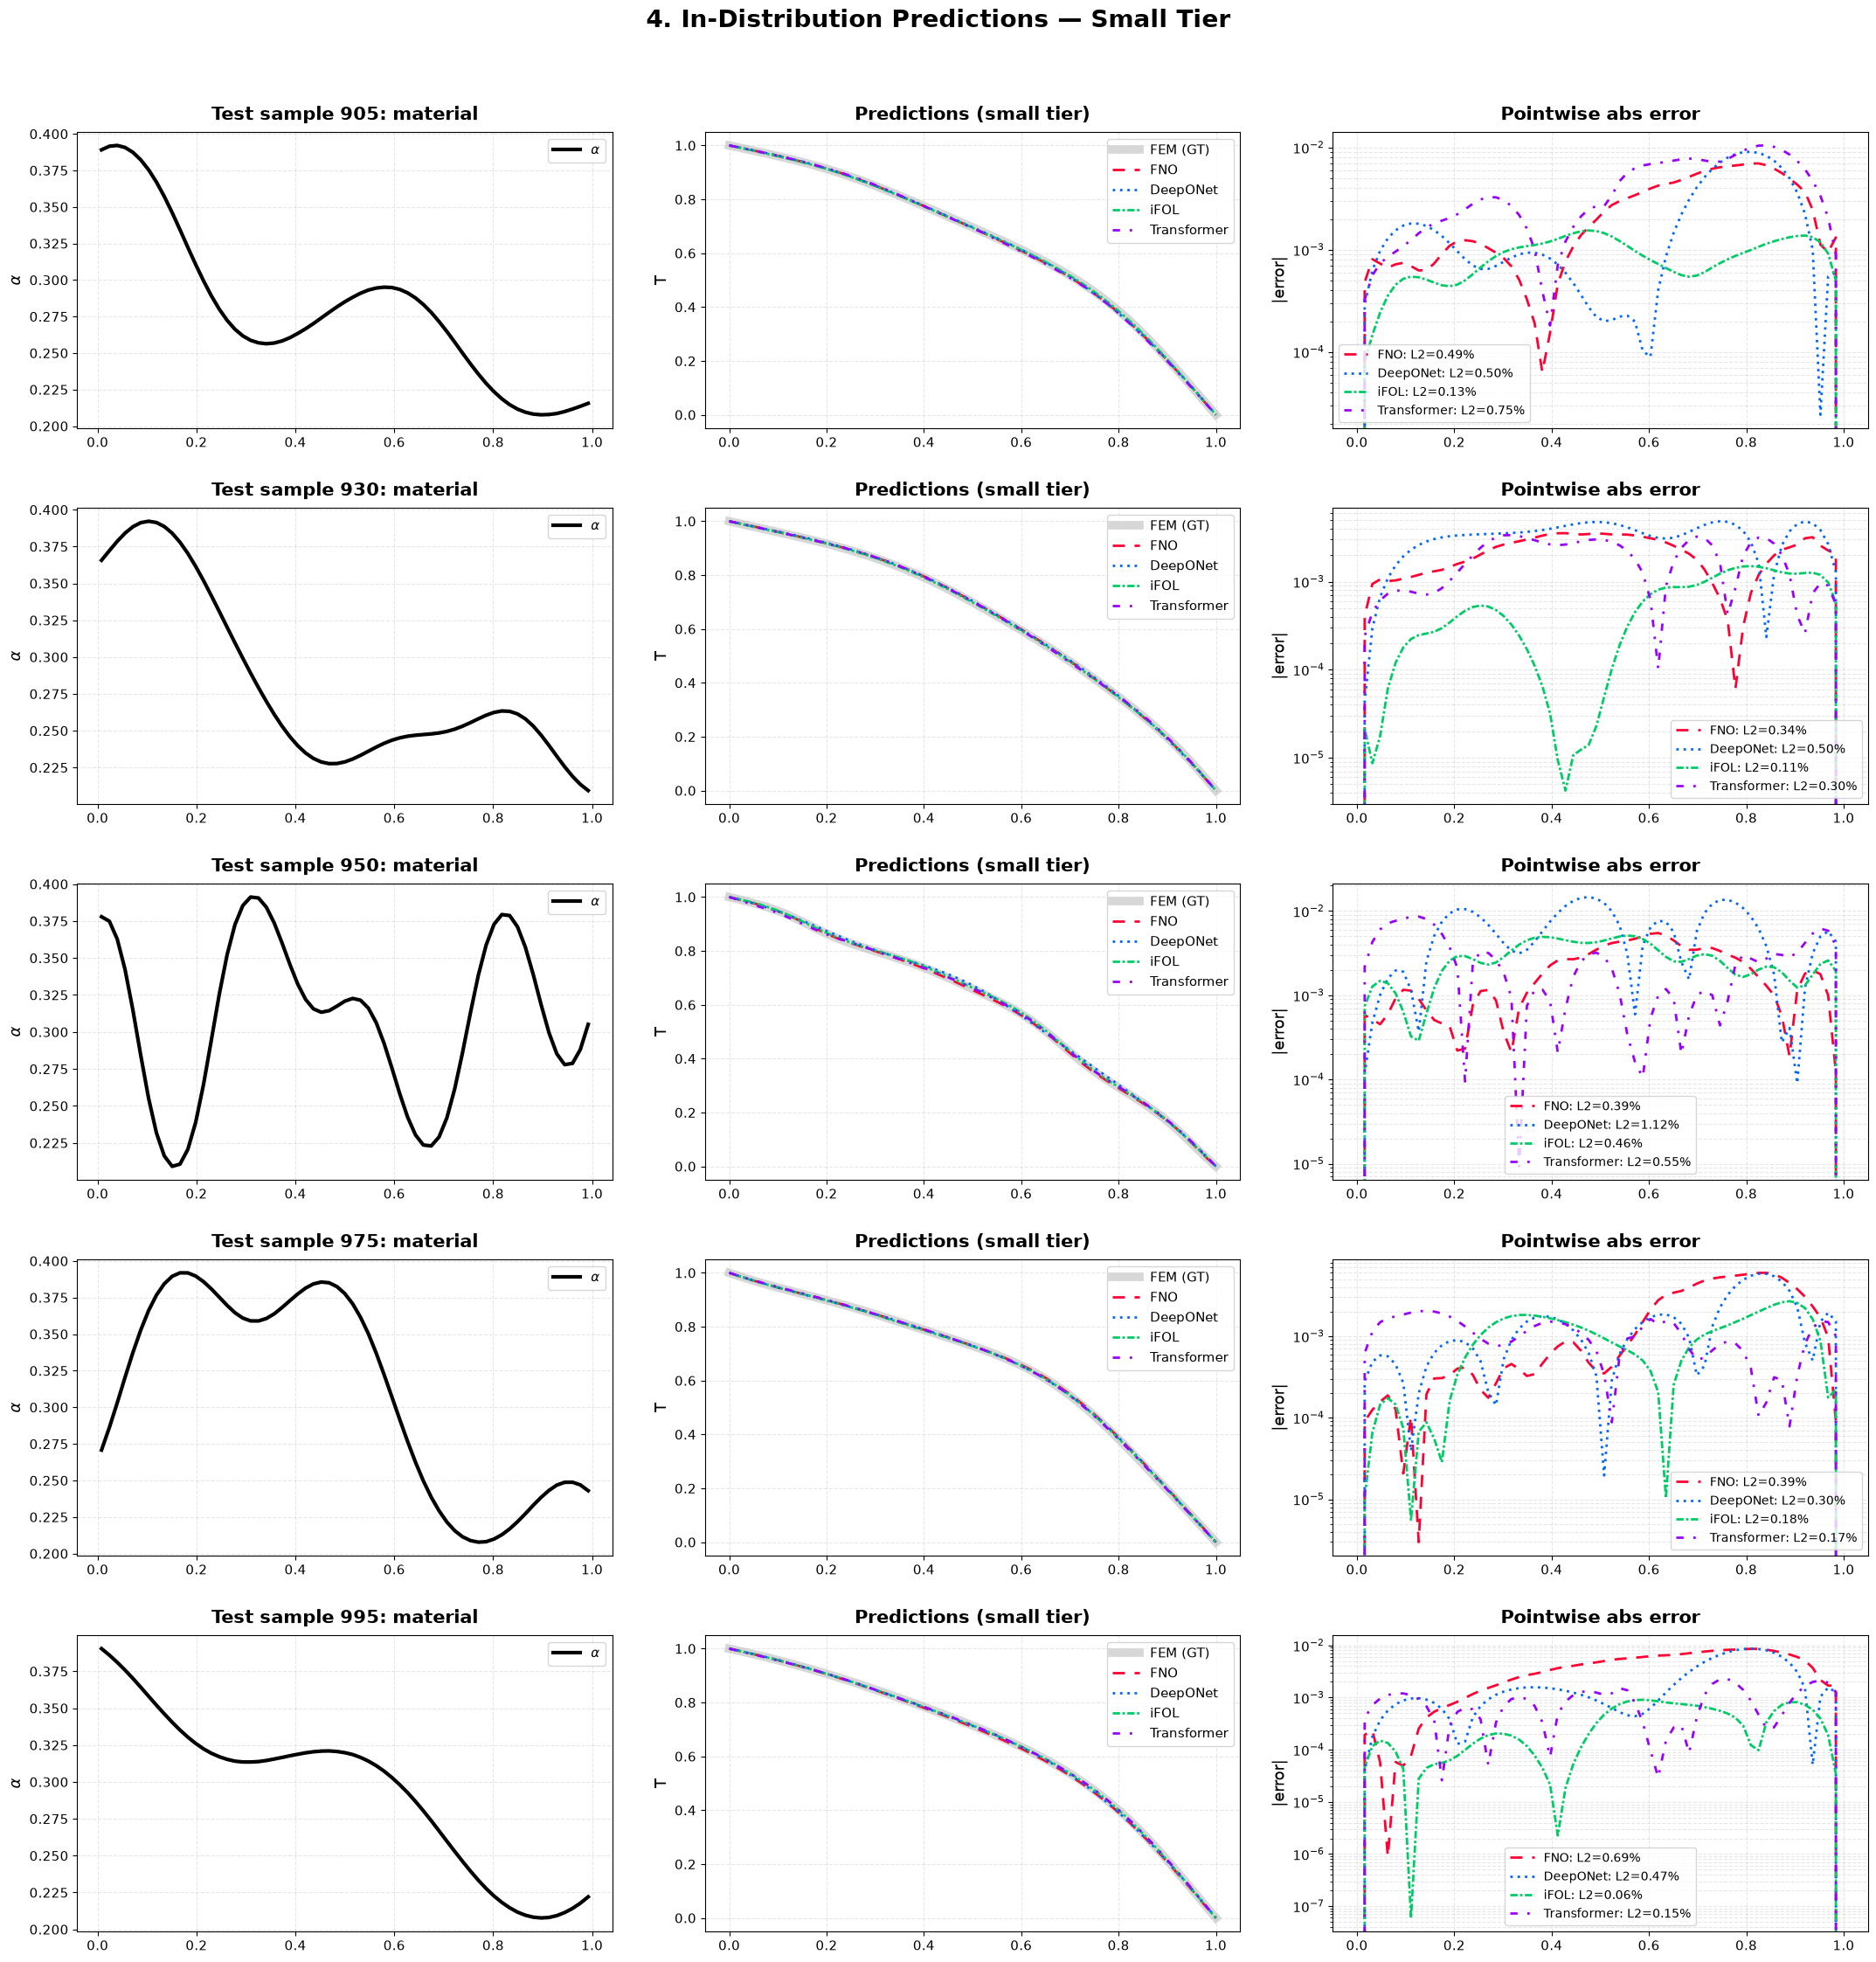

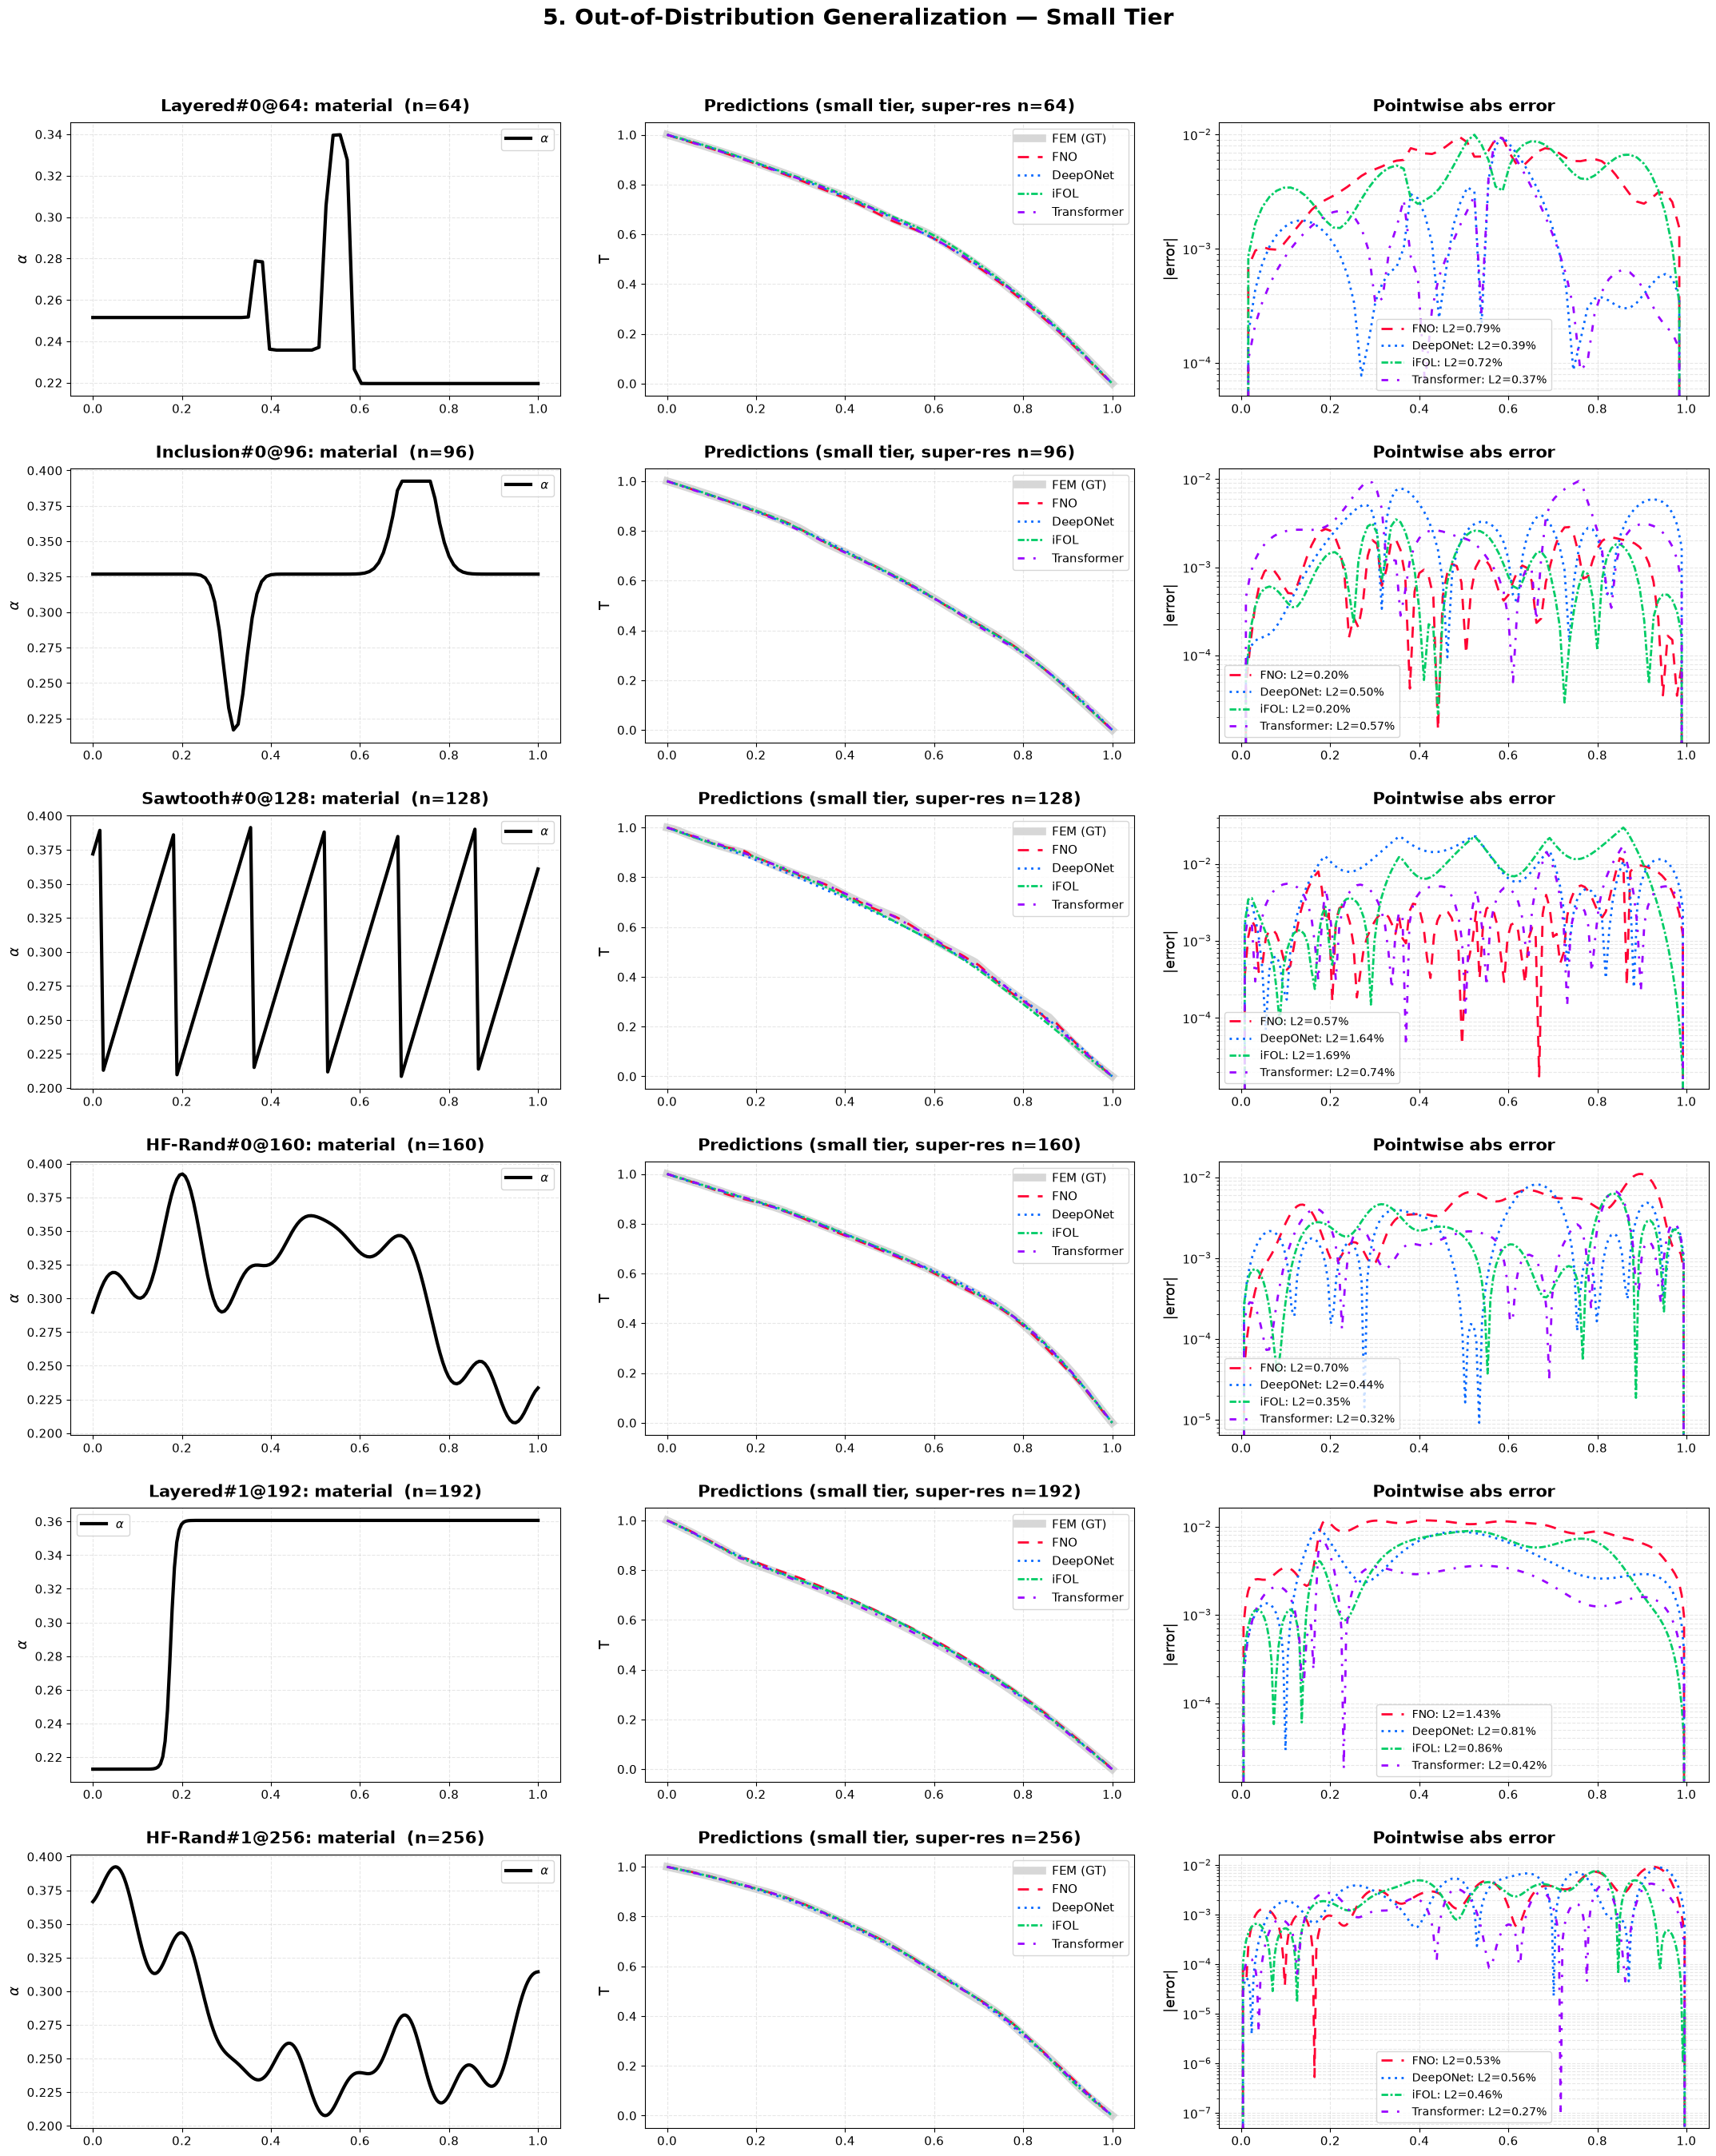


Generating plots for MEDIUM tier


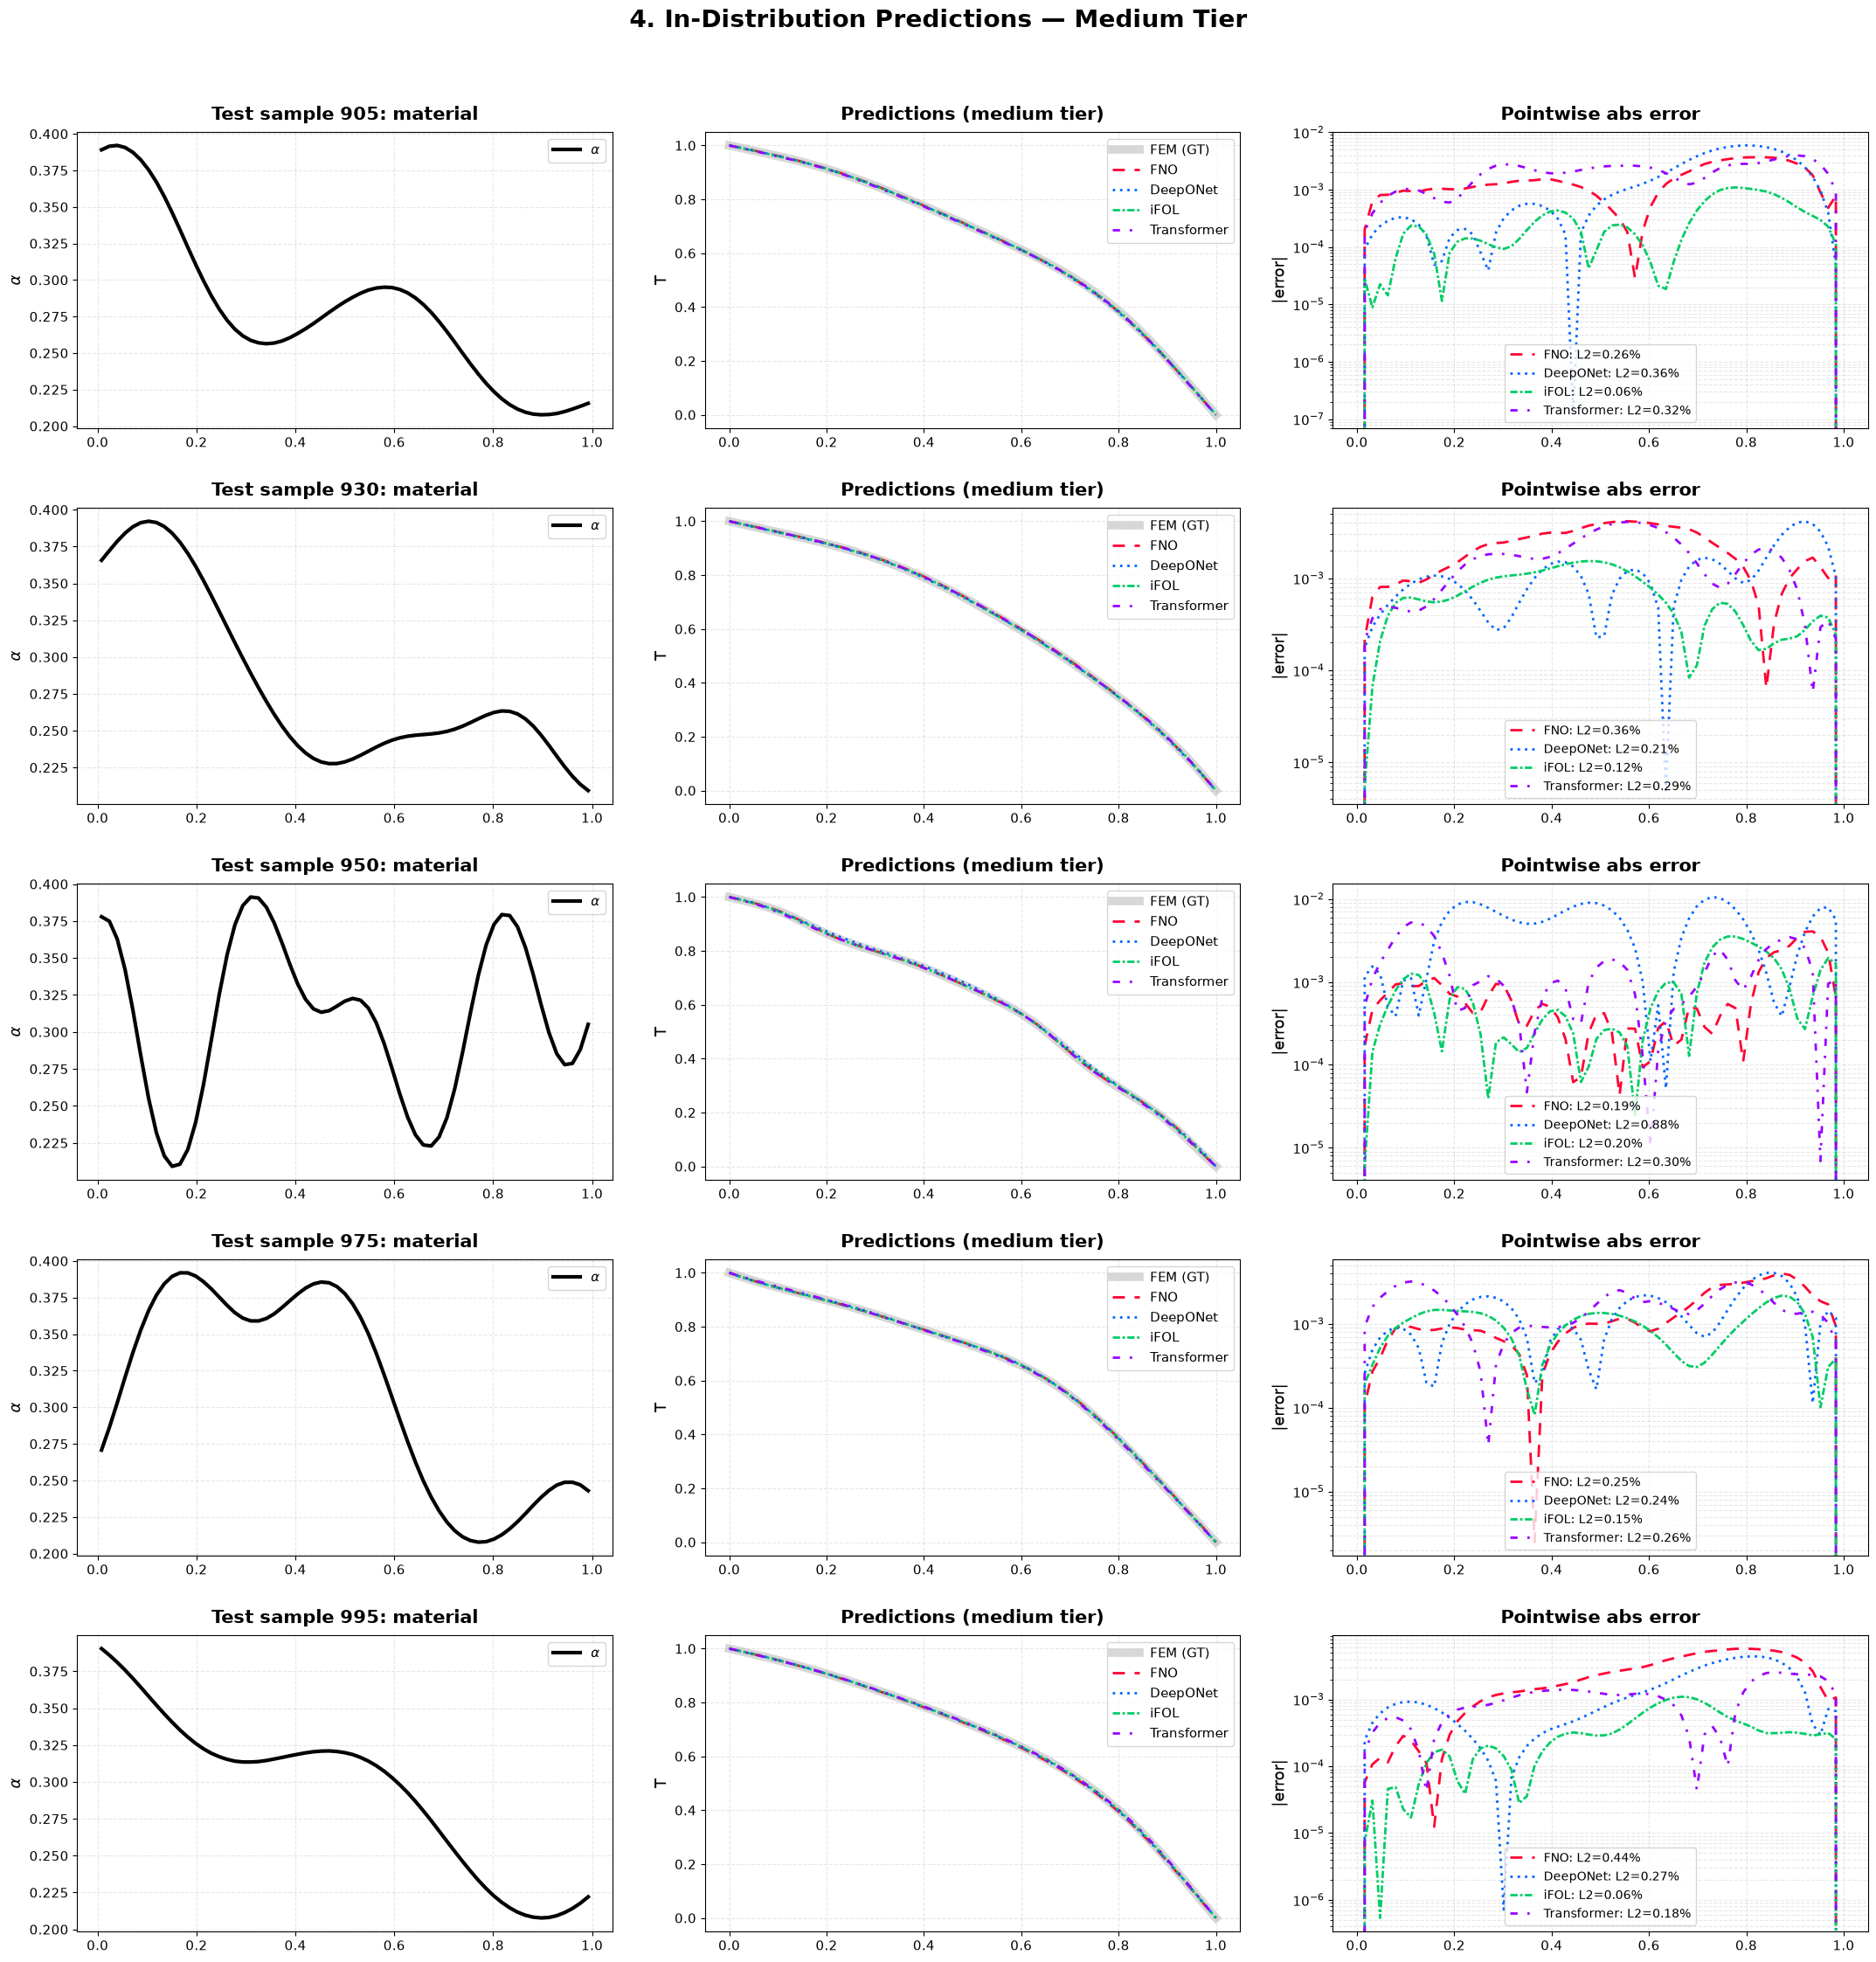

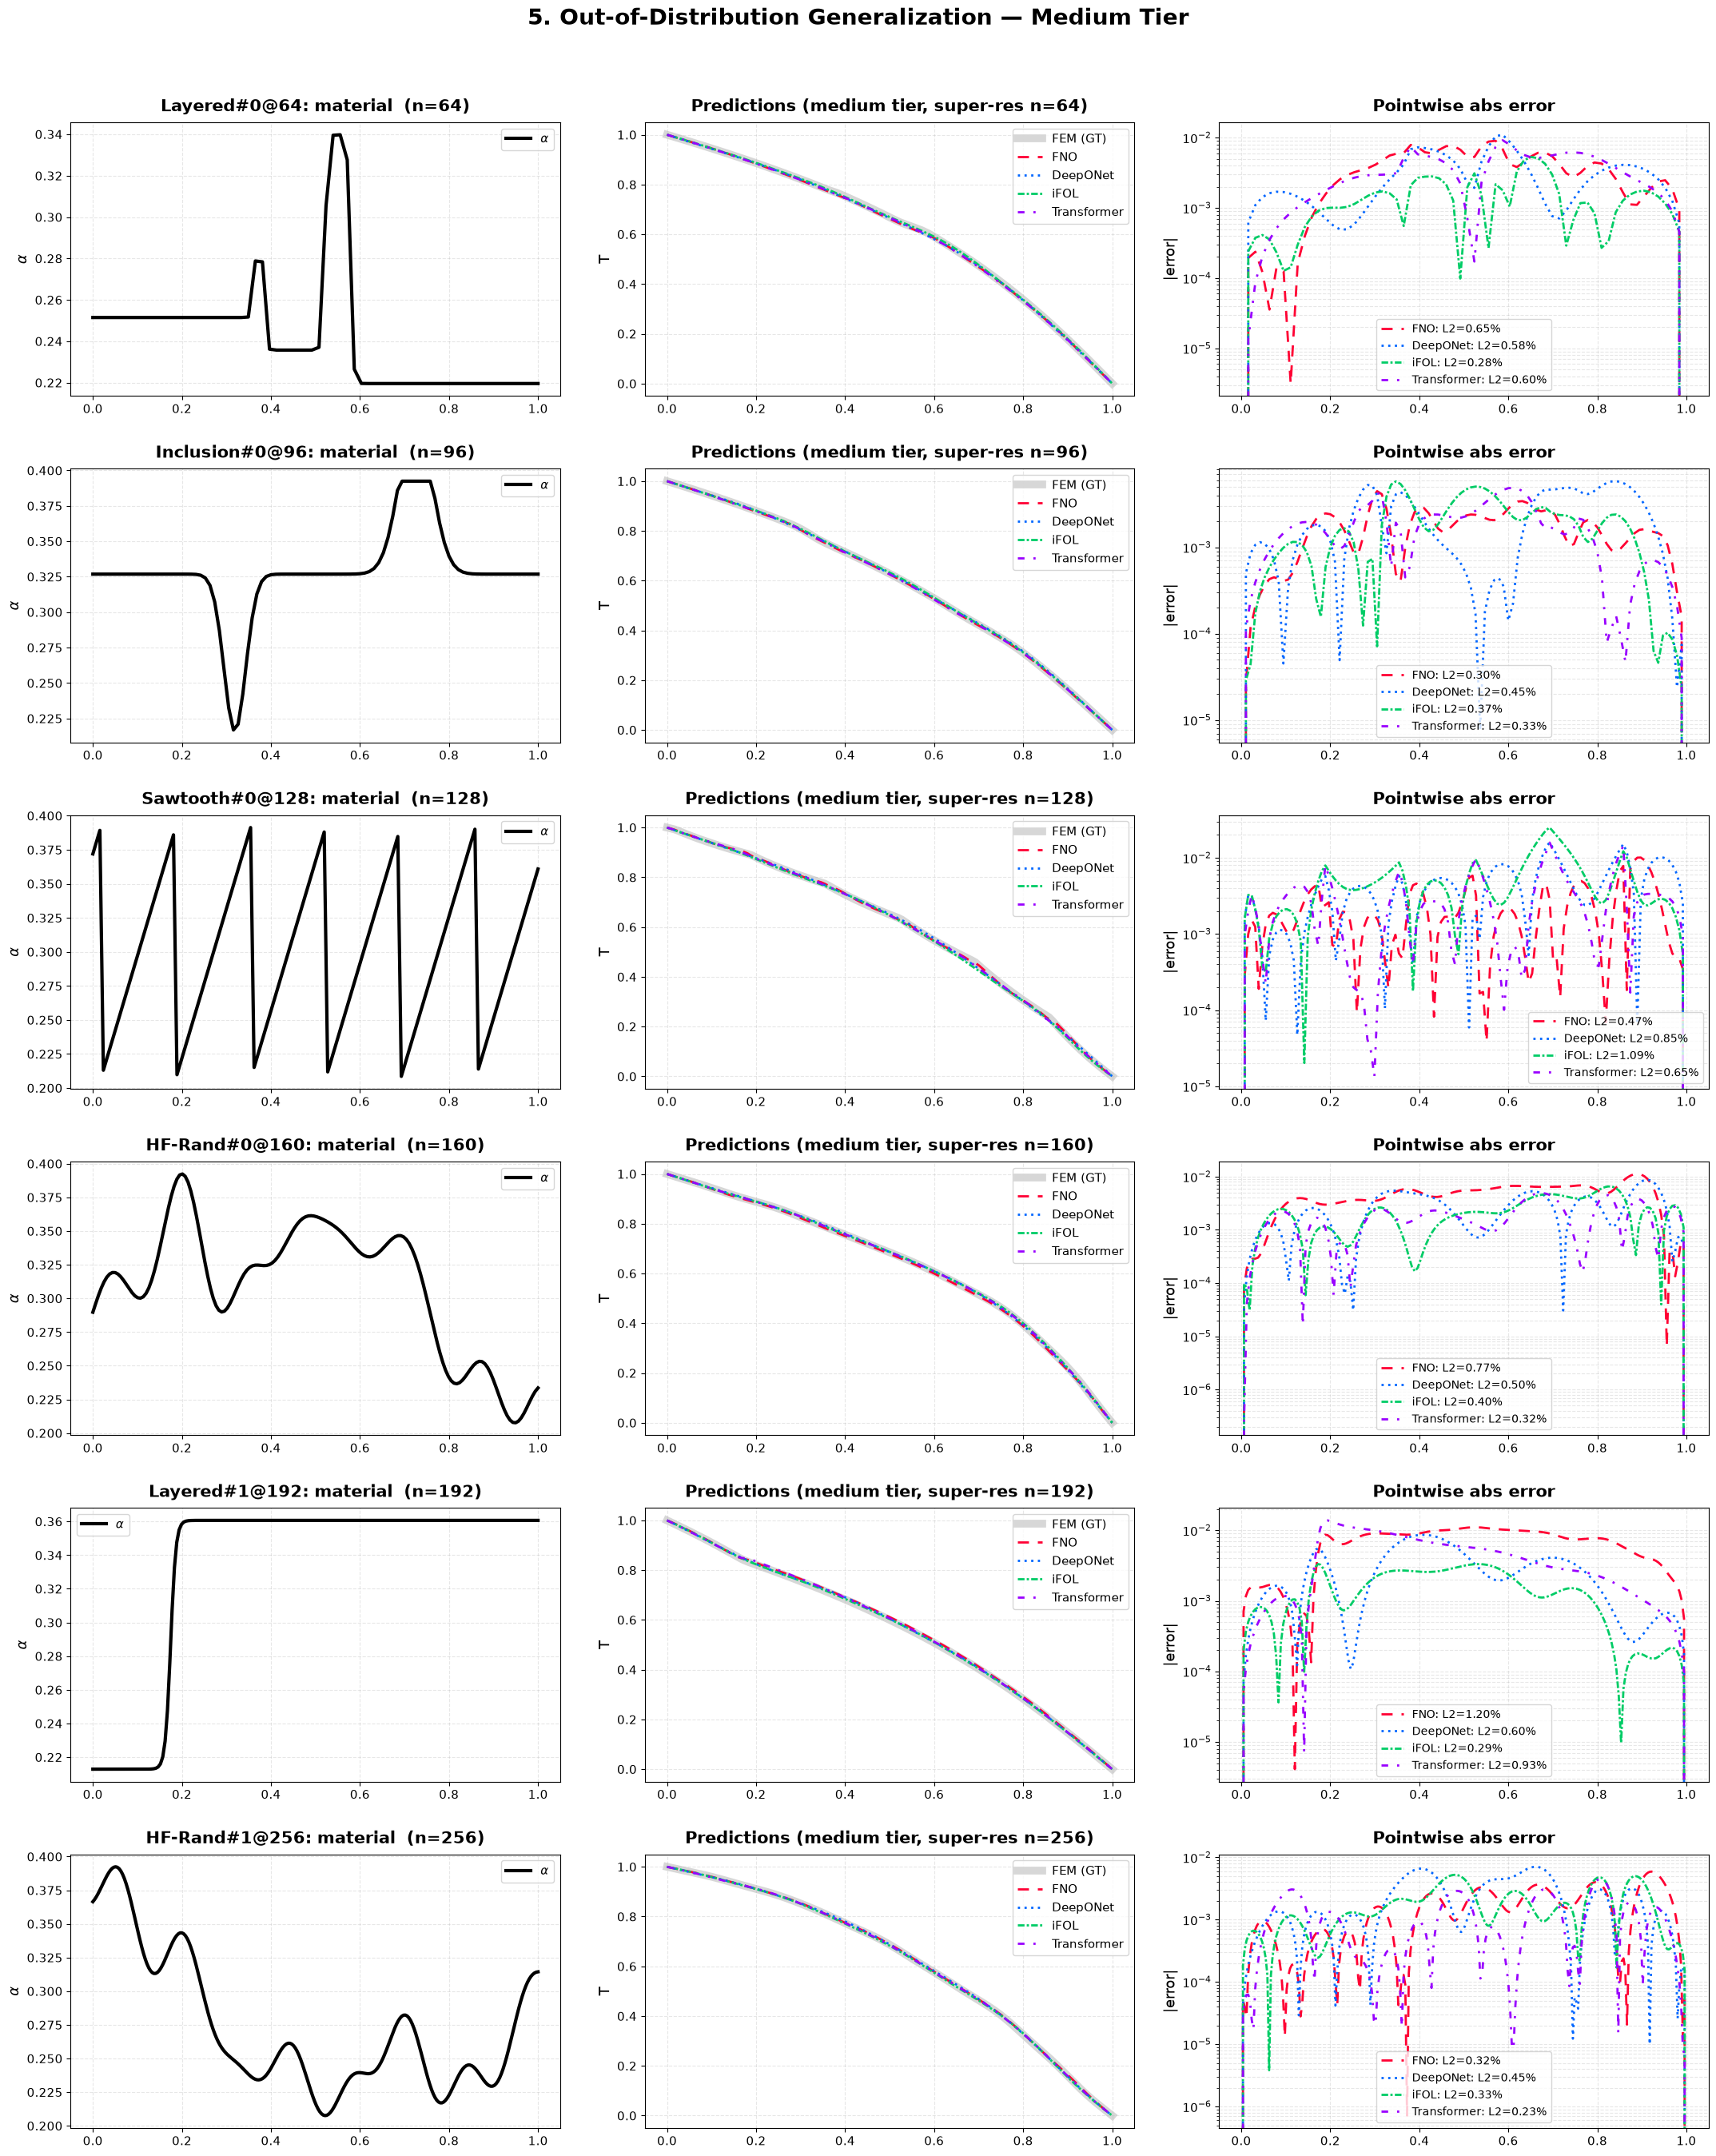


Generating plots for LARGE tier


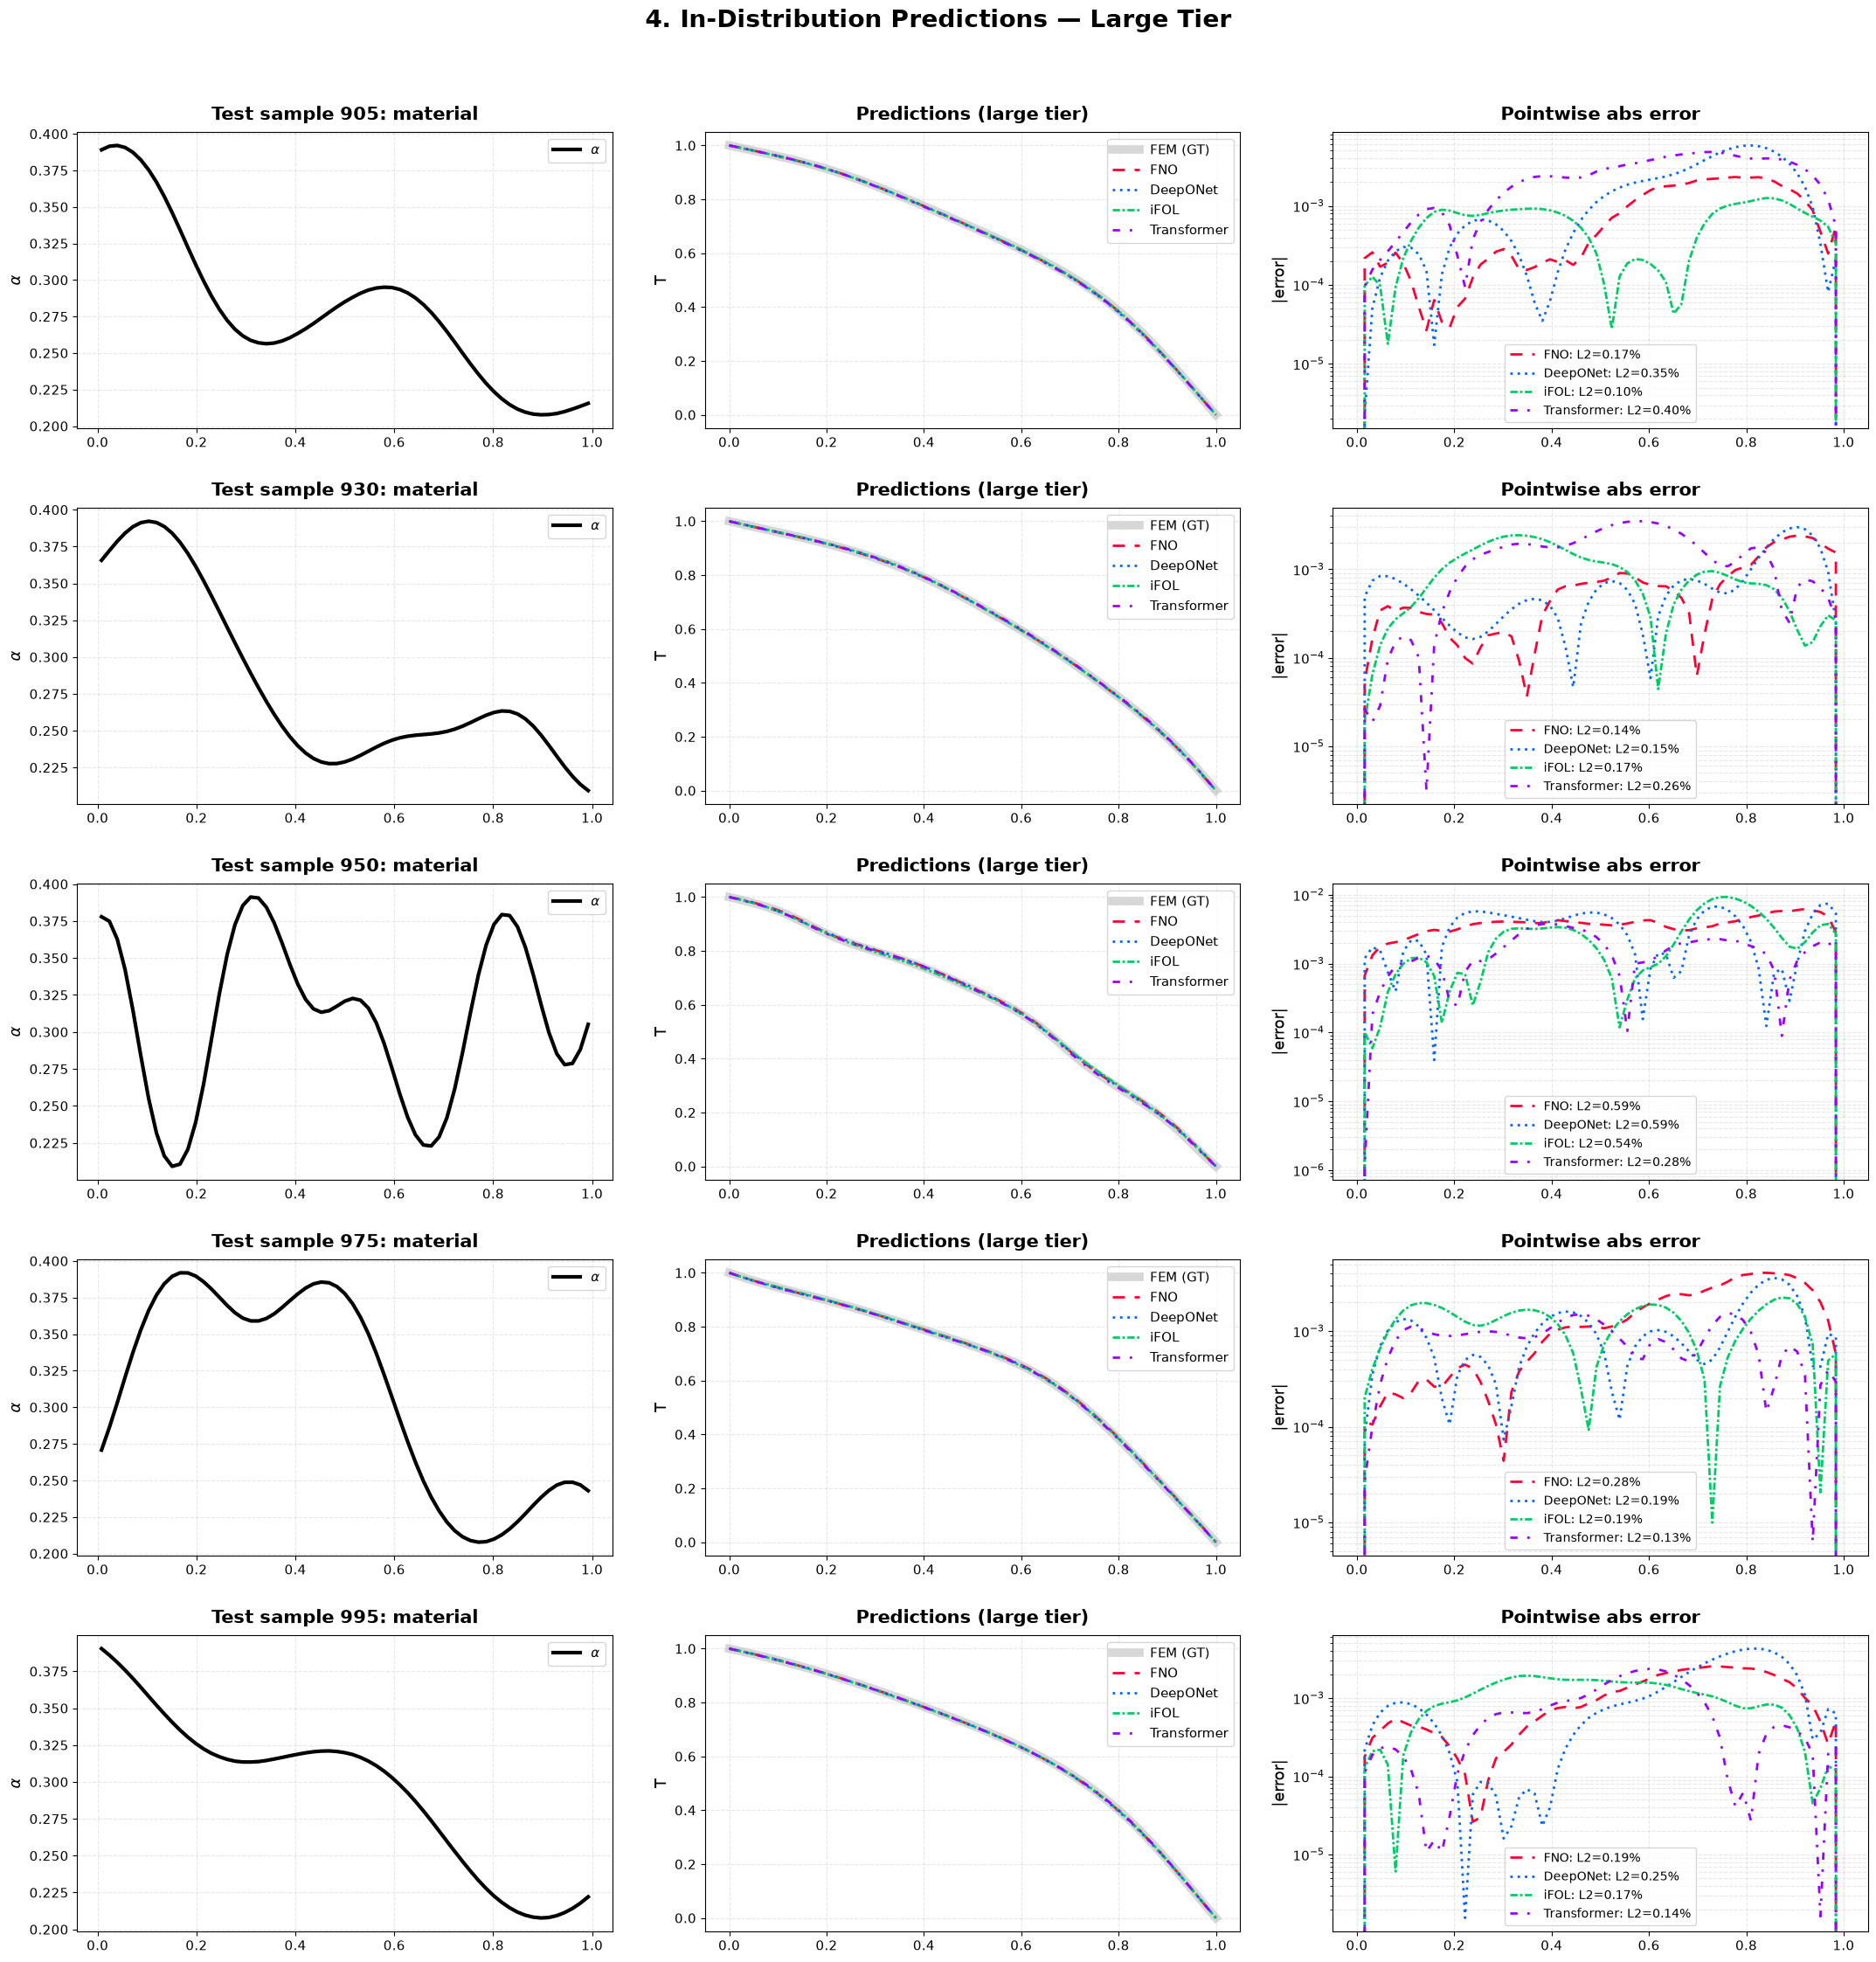

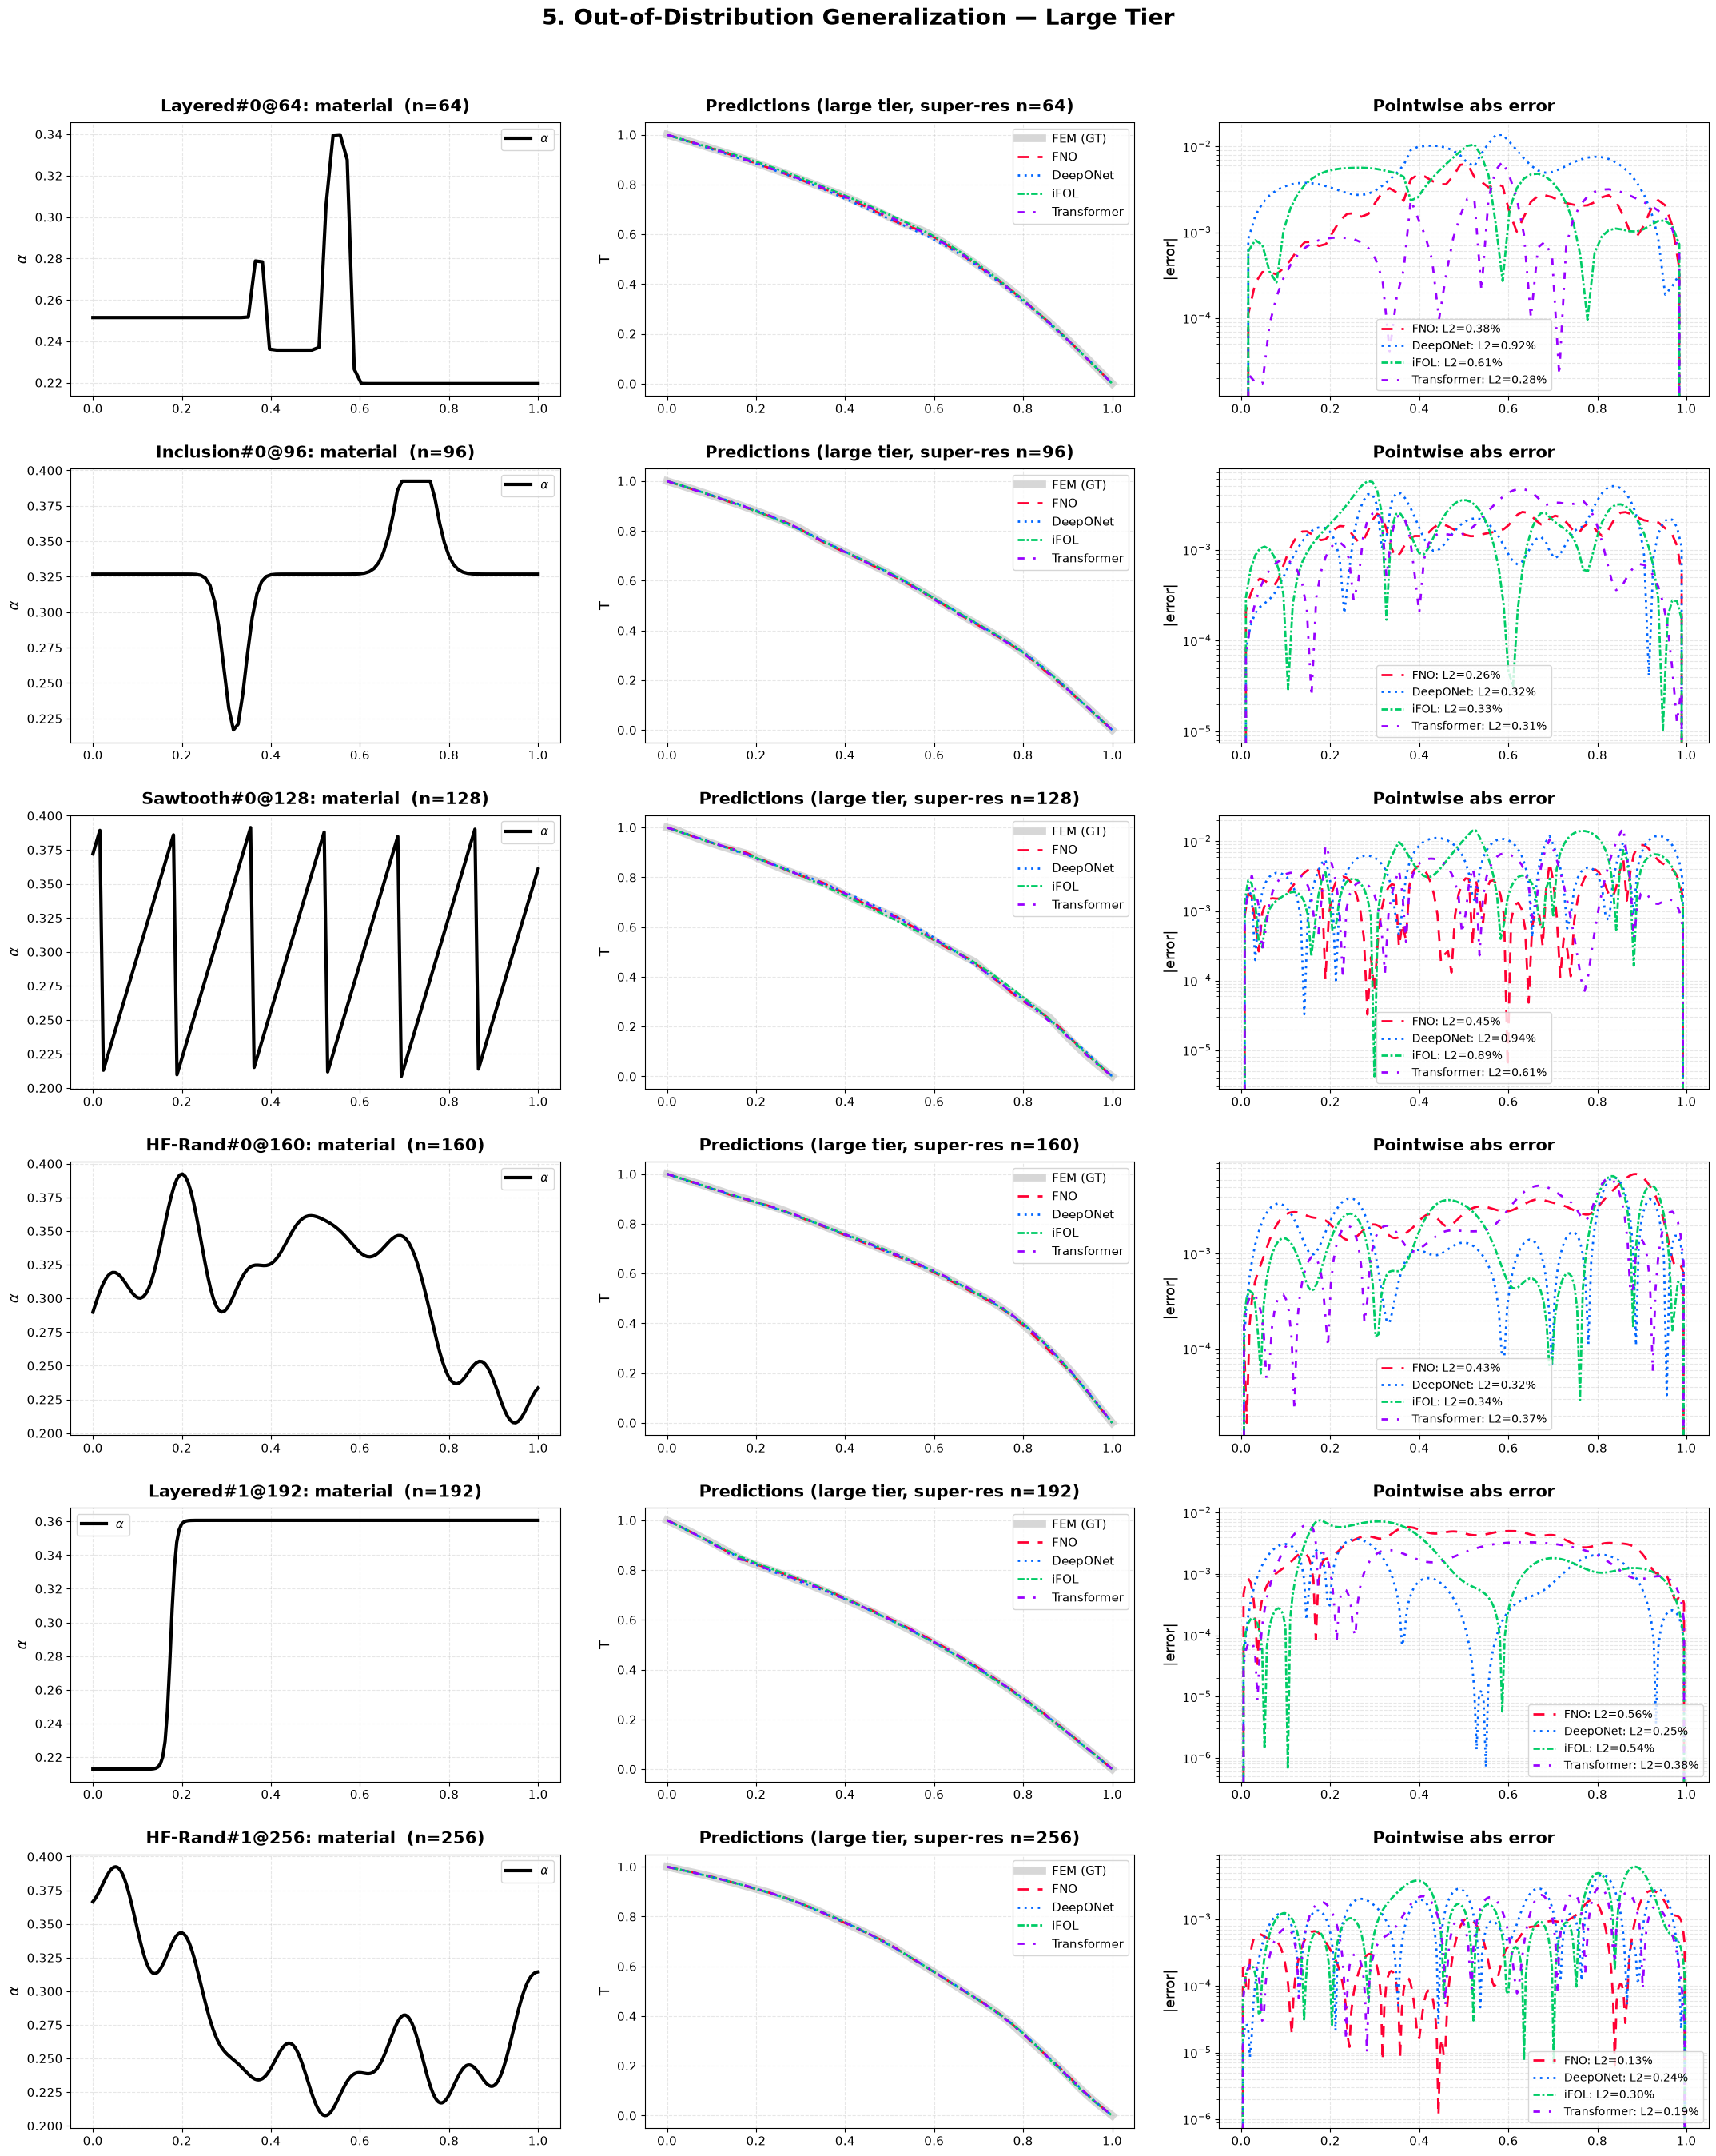


Done. Saved PNGs:
  plot4_indist_small.png, plot5_ood_small.png
  plot4_indist_medium.png, plot5_ood_medium.png
  plot4_indist_large.png, plot5_ood_large.png


In [3]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np

# Re-state styling (in case kernel was restarted)
plt.rcParams.update({
    'font.size': 13, 'axes.titlesize': 15, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
    'figure.titlesize': 20, 'lines.linewidth': 2.5,
})

# Maximum Contrast Palette (Far apart on the color wheel)
MODEL_COLORS = {
    "FNO": "#FF0033",        # Vivid Red
    "DeepONet": "#0066FF",   # Bright Blue
    "iFOL": "#00CC66",       # Bright Green
    "Transformer": "#9900FF" # Deep Violet
}

# Carefully staggered dash patterns so the gaps don't align
LINE_STYLES  = {
    "FNO": (0, (5, 4)),              # Long, evenly spaced dashes
    "DeepONet": (0, (1, 2)),         # Dense dots
    "iFOL": (0, (3, 1, 1, 1)),       # Standard dash-dot
    "Transformer": (0, (3, 4, 1, 4)) # Wide dash-dot to let others peek through
}

test_indices = [905, 930, 950, 975, 995]   # held-out test samples


def plot_in_distribution_for_tier(size_tier):
    """Plot 4 for a given tier (small / medium / large)."""
    fig, axes = plt.subplots(len(test_indices), 3, figsize=(22, 4.5*len(test_indices)))
    for i, idx in enumerate(test_indices):
        y_true = np.asarray(T_fem_dataset[idx])
        
        # Col 0: conductivity
        axes[i, 0].plot(np.asarray(x_elem_1d), np.asarray(k_dataset_elem[idx]), 'k', lw=3, label=r'$\alpha$')
        axes[i, 0].set_title(f'Test sample {idx}: material', fontweight='bold', pad=10)
        axes[i, 0].set_ylabel(r'$\alpha$')
        axes[i, 0].legend()
        axes[i, 0].grid(alpha=0.3, linestyle='--')

        # Col 1: predictions
        # FEM line: Thick, light grey track in the background (zorder=0)
        axes[i, 1].plot(np.asarray(GRID), y_true, color='#D3D3D3', lw=7.0, alpha=0.9, zorder=0, label='FEM (GT)')
        axes[i, 1].set_title(f'Predictions ({size_tier} tier)', fontweight='bold', pad=10)
        axes[i, 1].set_ylabel('T')

        # Col 2: errors
        axes[i, 2].set_yscale('log')
        axes[i, 2].set_title('Pointwise abs error', fontweight='bold', pad=10)
        axes[i, 2].set_ylabel('|error|')

        for name in model_order:
            cfg = SIZE_CONFIGS[size_tier][name]
            _, predict_fn = FACTORIES[name](**cfg)
            params = results[size_tier][name]['params_obj']
            if name == 'Transformer':
                y_pred = predict_fn(params, k_dataset_elem[idx], GRID, X_norm[idx])
            else:
                y_pred = predict_fn(params, k_dataset_elem[idx], GRID)
            y_pred = np.asarray(y_pred).flatten()
            error = np.abs(y_true.flatten() - y_pred)
            l2 = float(np.linalg.norm(y_true.flatten() - y_pred) / (np.linalg.norm(y_true.flatten()) + 1e-8))
            
            # Model predictions: Thinner lines, riding on top of the grey track (zorder=2)
            axes[i, 1].plot(np.asarray(GRID), y_pred, color=MODEL_COLORS[name],
                            ls=LINE_STYLES[name], lw=2.0, zorder=2, label=name)
            axes[i, 2].plot(np.asarray(GRID), error, color=MODEL_COLORS[name],
                            ls=LINE_STYLES[name], lw=2.0, label=f'{name}: L2={l2*100:.2f}%')

        axes[i, 1].legend(); axes[i, 1].grid(alpha=0.3, linestyle='--')
        axes[i, 2].legend(fontsize=10); axes[i, 2].grid(which='both', alpha=0.3, linestyle='--')
        
    fig.suptitle(f'4. In-Distribution Predictions — {size_tier.capitalize()} Tier',
                 fontweight='bold', y=1.005)
    plt.tight_layout(pad=2.0)
    plt.savefig(f'plot4_indist_{size_tier}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_ood_for_tier(size_tier):
    """Plot 5 for a given tier — 6 super-resolution scenarios."""
    gt = OOD_PLOT_GT
    fig, axes = plt.subplots(len(gt), 3, figsize=(22, 4.5 * len(gt)))
    for i, (title, k_prof, gl, k_elem_local, y_fem) in enumerate(gt):
        gl_np, y_fem_np = np.asarray(gl), np.asarray(y_fem)
        n = gl_np.shape[0]

        axes[i, 0].plot(gl_np, np.asarray(k_prof), 'k', lw=3, label=r'$\alpha$')
        axes[i, 0].set_title(f'{title}: material  (n={n})', fontweight='bold', pad=10)
        axes[i, 0].set_ylabel(r'$\alpha$'); axes[i, 0].legend(); axes[i, 0].grid(alpha=0.3, linestyle='--')

        axes[i, 1].plot(gl_np, y_fem_np, color='#D3D3D3', lw=7.0, alpha=0.9, zorder=0, label='FEM (GT)')
        axes[i, 1].set_title(f'Predictions ({size_tier} tier, super-res n={n})', fontweight='bold', pad=10)
        axes[i, 1].set_ylabel('T')

        axes[i, 2].set_yscale('log')
        axes[i, 2].set_title('Pointwise abs error', fontweight='bold', pad=10)
        axes[i, 2].set_ylabel('|error|')

        for name in model_order:
            cfg = SIZE_CONFIGS[size_tier][name]
            _, predict_fn = FACTORIES[name](**cfg)
            params = results[size_tier][name]['params_obj']
            if name == 'Transformer':
                x_norm_local = (jnp.stack([k_prof, gl], axis=-1) - x_mean) / x_std
                y_pred = predict_fn(params, k_elem_local, gl, x_norm_local)
            else:
                y_pred = predict_fn(params, k_elem_local, gl)
            y_pred = np.asarray(y_pred).flatten()
            error = np.abs(y_fem_np - y_pred)
            l2 = float(np.linalg.norm(y_fem_np - y_pred) / (np.linalg.norm(y_fem_np) + 1e-8))
            axes[i, 1].plot(gl_np, y_pred, color=MODEL_COLORS[name], ls=LINE_STYLES[name],
                            lw=2.0, zorder=2, label=name)
            axes[i, 2].plot(gl_np, error, color=MODEL_COLORS[name], ls=LINE_STYLES[name],
                            lw=2.0, label=f'{name}: L2={l2*100:.2f}%')

        axes[i, 1].legend(); axes[i, 1].grid(alpha=0.3, linestyle='--')
        axes[i, 2].legend(fontsize=10); axes[i, 2].grid(which='both', alpha=0.3, linestyle='--')

    fig.suptitle(f'5. Out-of-Distribution Generalization — {size_tier.capitalize()} Tier',
                 fontweight='bold', y=1.005)
    plt.tight_layout(pad=2.0)
    plt.savefig(f'plot5_ood_{size_tier}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Generate plots for small, medium, and large
for tier in ['small', 'medium', 'large']:    
    print(f"\n{'='*60}")
    print(f"Generating plots for {tier.upper()} tier")
    print(f"{'='*60}")
    plot_in_distribution_for_tier(tier)
    plot_ood_for_tier(tier)

print("\nDone. Saved PNGs:")
print("  plot4_indist_small.png, plot5_ood_small.png")
print("  plot4_indist_medium.png, plot5_ood_medium.png")
print("  plot4_indist_large.png, plot5_ood_large.png")

## 9. Error distributions: train vs. held-out test vs. OOD

A compact summary of accuracy for every model and tier across the three regimes: box plots of the per-sample mean absolute error, grouped by capacity tier and coloured by architecture.

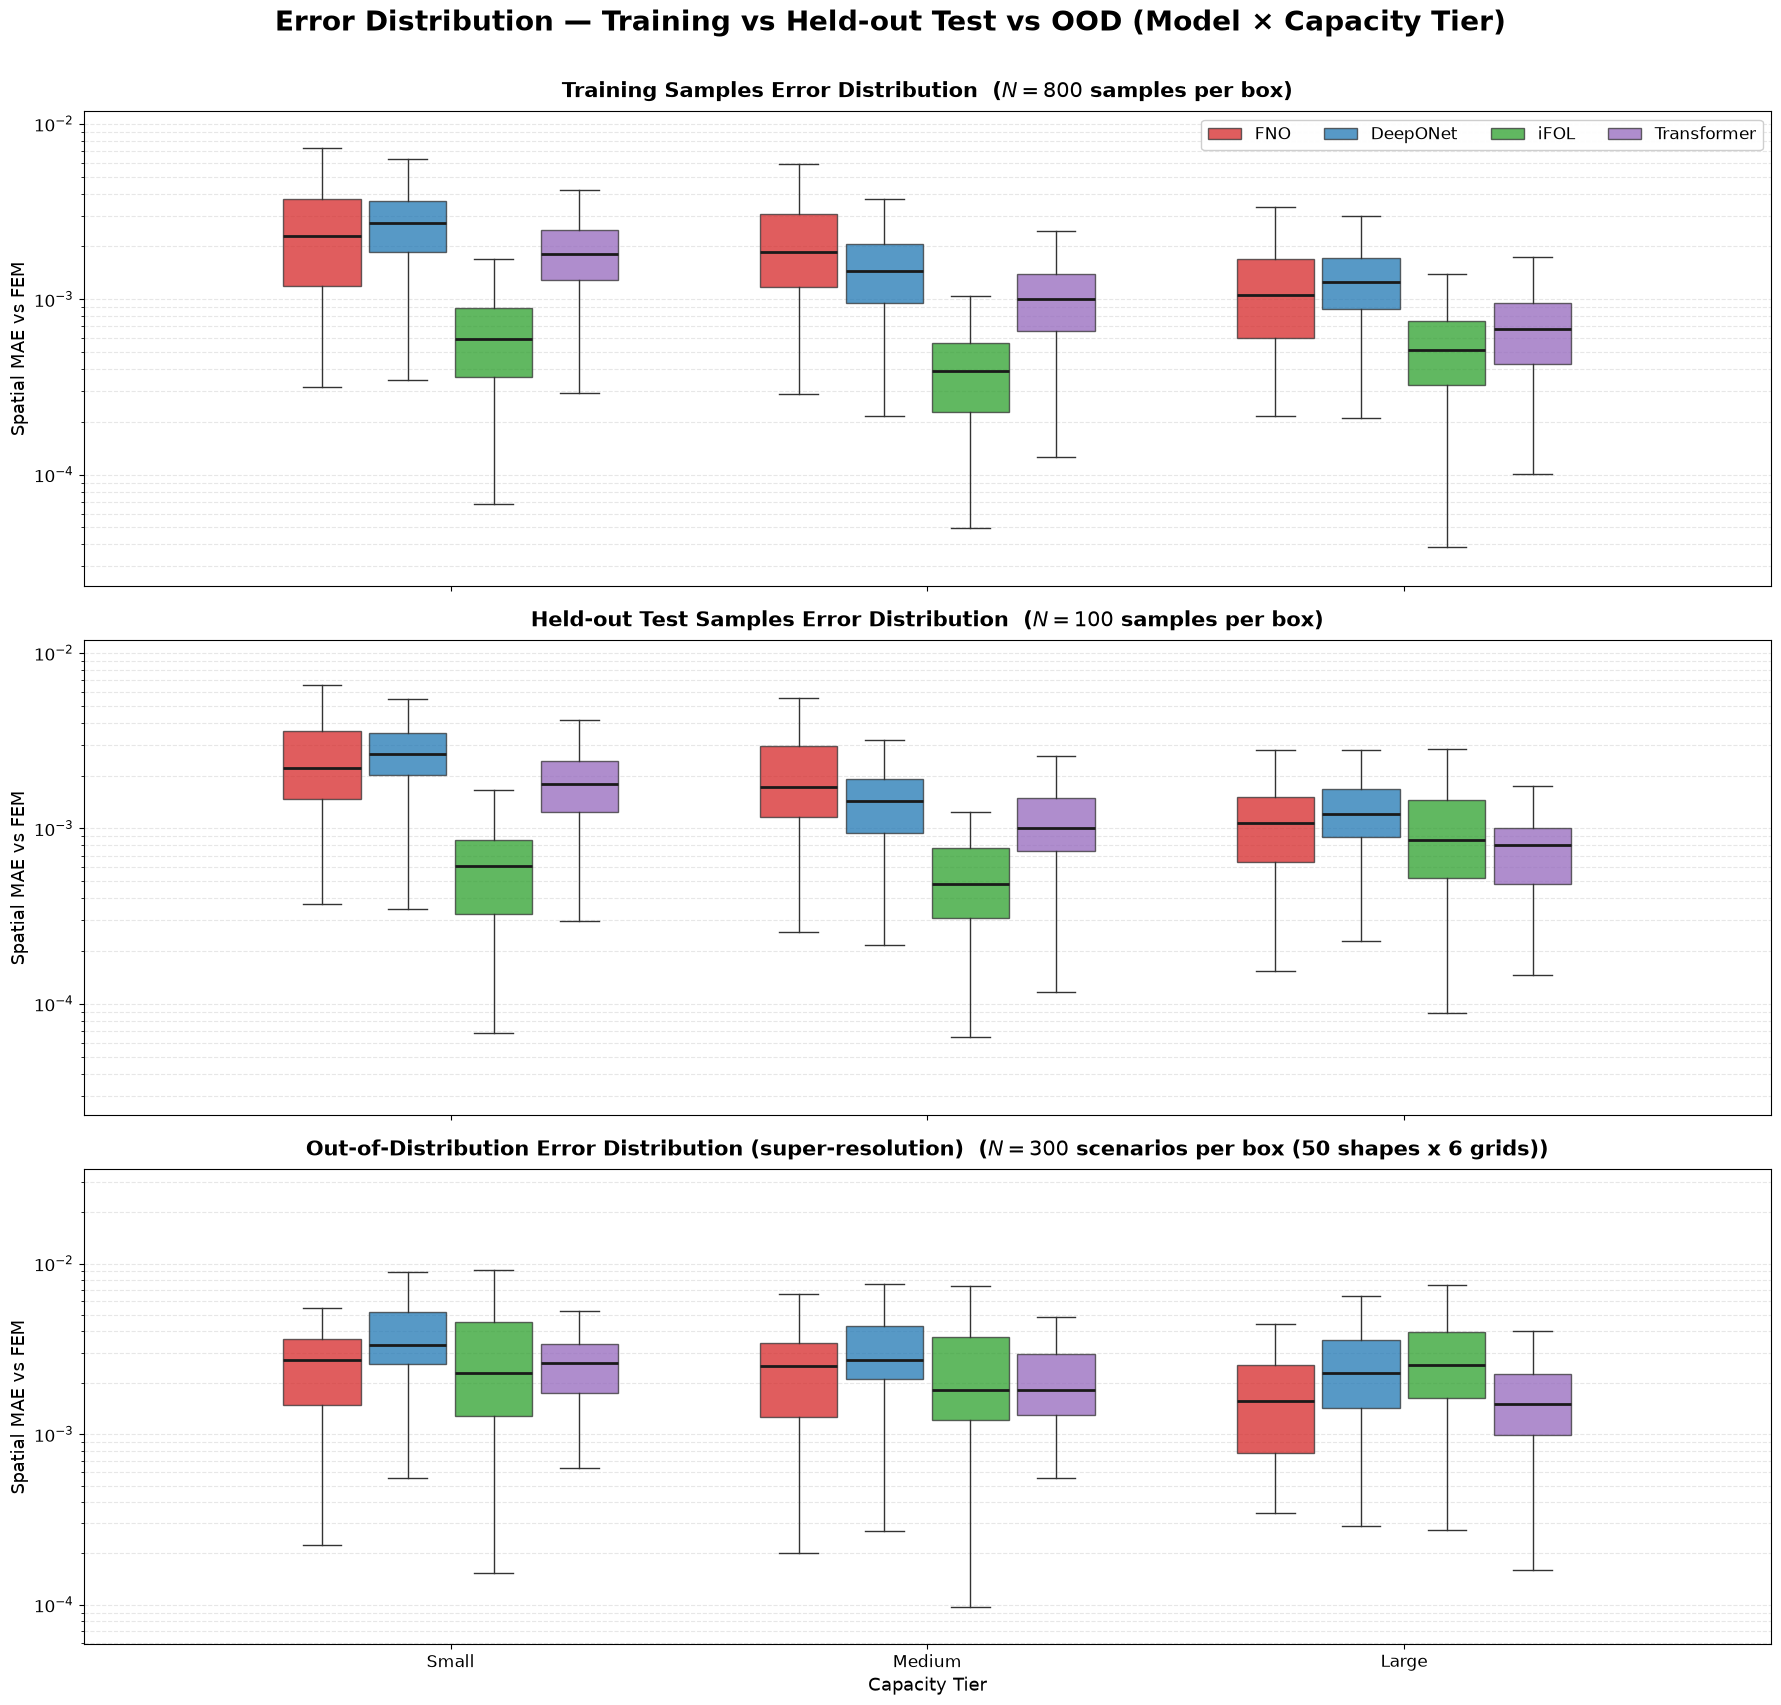


Saved: plot_error_train_val_ood.png


In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import jax
import jax.numpy as jnp

size_order = ["small", "medium", "large"]
model_order = ["FNO", "DeepONet", "iFOL", "Transformer"]
MODEL_COLORS = {"FNO": "#D62728", "DeepONet": "#1F77B4", "iFOL": "#2CA02C", "Transformer": "#9467BD"}

plt.rcParams.update({
    'font.size': 13, 'axes.titlesize': 15, 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 12,
    'figure.titlesize': 20,
})

T_fem_train = T_fem_dataset[:N_TRAIN]

# ---- per-sample MAE helpers ----
def _pred_fn(name, predict_fn):
    return (lambda p, k, x: predict_fn(p, k, GRID, x)) if name == "Transformer" \
           else (lambda p, k, x: predict_fn(p, k, GRID))

def get_train_maes(size, name):
    cfg = SIZE_CONFIGS[size][name]; _, predict_fn = FACTORIES[name](**cfg)
    params = results[size][name]['params_obj']
    preds = jax.vmap(_pred_fn(name, predict_fn), in_axes=(None, 0, 0))(params, k_train_elem, X_train_norm)
    return np.asarray(jnp.mean(jnp.abs(preds - T_fem_train), axis=1))

def get_val_maes(size, name):
    cfg = SIZE_CONFIGS[size][name]; _, predict_fn = FACTORIES[name](**cfg)
    params = results[size][name]['params_obj']
    preds = jax.vmap(_pred_fn(name, predict_fn), in_axes=(None, 0, 0))(params, k_val_elem, X_val_norm)
    return np.asarray(jnp.mean(jnp.abs(preds - T_fem_val), axis=1))

def get_ood_maes(size, name):
    cfg = SIZE_CONFIGS[size][name]; _, predict_fn = FACTORIES[name](**cfg)
    params = results[size][name]['params_obj']
    maes = []
    for (title, k_prof, gl, k_elem_local, y_fem) in OOD_GT:
        if name == 'Transformer':
            x_norm_local = (jnp.stack([k_prof, gl], axis=-1) - x_mean) / x_std
            y_pred = predict_fn(params, k_elem_local, gl, x_norm_local)
        else:
            y_pred = predict_fn(params, k_elem_local, gl)
        y_pred = np.asarray(y_pred).flatten()
        maes.append(float(np.mean(np.abs(np.asarray(y_fem).flatten() - y_pred))))
    return np.array(maes)

# ---- layout ----
colors = [MODEL_COLORS[m] for m in model_order]
box_width = 0.18
group_center = np.arange(len(size_order))
offsets = np.linspace(-1.5, 1.5, len(model_order)) * box_width

positions, box_colors = [], []
train_data, val_data, ood_data = [], [], []
for gi, size in enumerate(size_order):
    for mi, name in enumerate(model_order):
        positions.append(group_center[gi] + offsets[mi])
        box_colors.append(colors[mi])
        train_data.append(get_train_maes(size, name))
        val_data.append(get_val_maes(size, name))
        ood_data.append(get_ood_maes(size, name))

# ---- box drawer ----
def draw_box(ax, data, positions, box_colors, title, n_per_box_str):
    bp = ax.boxplot(data, positions=positions, widths=box_width*0.9, patch_artist=True,
                    medianprops=dict(color='#1a1a1a', linewidth=2),
                    whiskerprops=dict(color='#333333'), capprops=dict(color='#333333'),
                    flierprops=dict(marker='o', markersize=3, alpha=0.35, markeredgecolor='none'))
    for patch, c in zip(bp['boxes'], box_colors):
        patch.set_facecolor(c); patch.set_alpha(0.75); patch.set_edgecolor('#333333')
    ax.set_yscale('log')
    ax.set_ylabel('Spatial MAE vs FEM')
    ax.set_title(f'{title}  ({n_per_box_str})', fontweight='bold', pad=10)
    ax.grid(True, axis='y', which='both', alpha=0.3, linestyle='--')

# ---- 3-panel figure ----
fig, axes = plt.subplots(3, 1, figsize=(18, 17), sharex=True)

draw_box(axes[0], train_data, positions, box_colors,
         'Training Samples Error Distribution',          f'$N={N_TRAIN}$ samples per box')
draw_box(axes[1], val_data, positions, box_colors,
         'Held-out Test Samples Error Distribution', f'$N={len(T_fem_val)}$ samples per box')
draw_box(axes[2], ood_data, positions, box_colors,
         'Out-of-Distribution Error Distribution (super-resolution)',
         f'$N={N_OOD}$ scenarios per box (50 shapes x 6 grids)')

legend_elems = [Patch(facecolor=colors[i], alpha=0.75, edgecolor='#333333', label=model_order[i])
                for i in range(len(model_order))]
axes[0].legend(handles=legend_elems, loc='upper right', ncol=4, framealpha=0.95)

axes[2].set_xticks(group_center)
axes[2].set_xticklabels([s.capitalize() for s in size_order])
axes[2].set_xlabel('Capacity Tier')

tv = np.concatenate([np.concatenate(train_data), np.concatenate(val_data)])
axes[0].set_ylim(tv.min()*0.6, tv.max()*1.5)
axes[1].set_ylim(tv.min()*0.6, tv.max()*1.5)
od = np.concatenate(ood_data)
axes[2].set_ylim(od.min()*0.6, od.max()*1.5)

fig.suptitle('Error Distribution — Training vs Held-out Test vs OOD (Model × Capacity Tier)',
             fontweight='bold', y=1.003)
plt.tight_layout()
plt.savefig('plot_error_train_val_ood.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: plot_error_train_val_ood.png")

## 10. Convergence behaviour

Training-loss trajectories for all models, one panel per capacity tier. The weighted-residual loss is signed, so its value is not an error measure. What matters is how quickly and how smoothly each architecture settles.

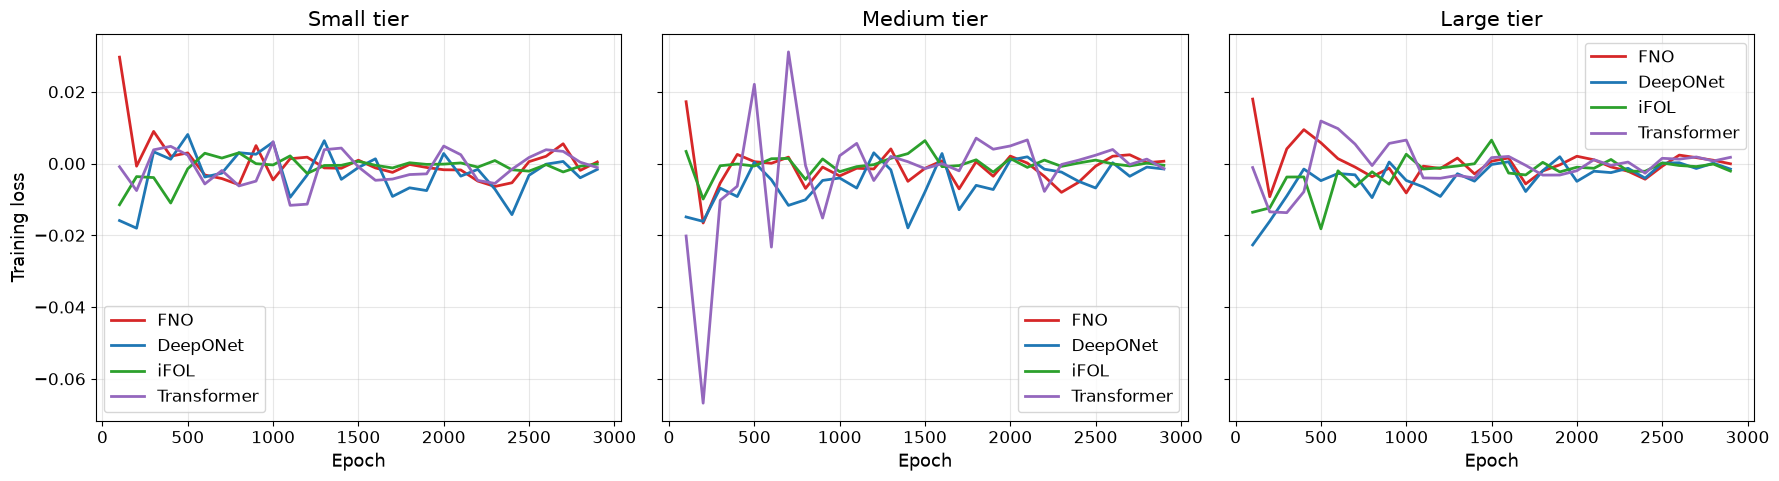

In [6]:
import numpy as np
import matplotlib.pyplot as plt

MODEL_COLORS = {"FNO": "#D62728", "DeepONet": "#1F77B4", "iFOL": "#2CA02C", "Transformer": "#9467BD"}
SKIP = 1   # drop the first logged point (the init spike); bump to 2 if needed

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, size in enumerate(size_order):
    ax = axes[i]
    for name in model_order:
        h = results[size][name]["history"]
        ax.plot(h['step'][SKIP:], h['train_loss'][SKIP:], color=MODEL_COLORS[name], lw=2, label=name)
    ax.set_title(f'{size.capitalize()} tier')
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel('Training loss')
plt.tight_layout()
plt.show()

## 11. iFOL learned frequencies

The iFOL variant learns one frequency parameter $\omega$ per layer, initialized at 5 (small, medium) or 3 (large). The values printed below show how far training moved them.

In [5]:
for size in size_order:
    p = results[size]["iFOL"]["params_obj"]
    print(size, "learned omega:", np.round(np.asarray(p['omega']), 2))

small learned omega: [4.96 4.88 4.8  5.  ]
medium learned omega: [4.87 4.93 4.93 5.  ]
large learned omega: [2.94 2.93 2.95 3.  ]


## 12. Computational cost

Total training time and per-batch inference time (100 held-out samples) as a function of the capacity tier, exposing the accuracy/cost trade-off between architectures.

Benchmarking inference times over 20 runs per model (batch size = 100)...


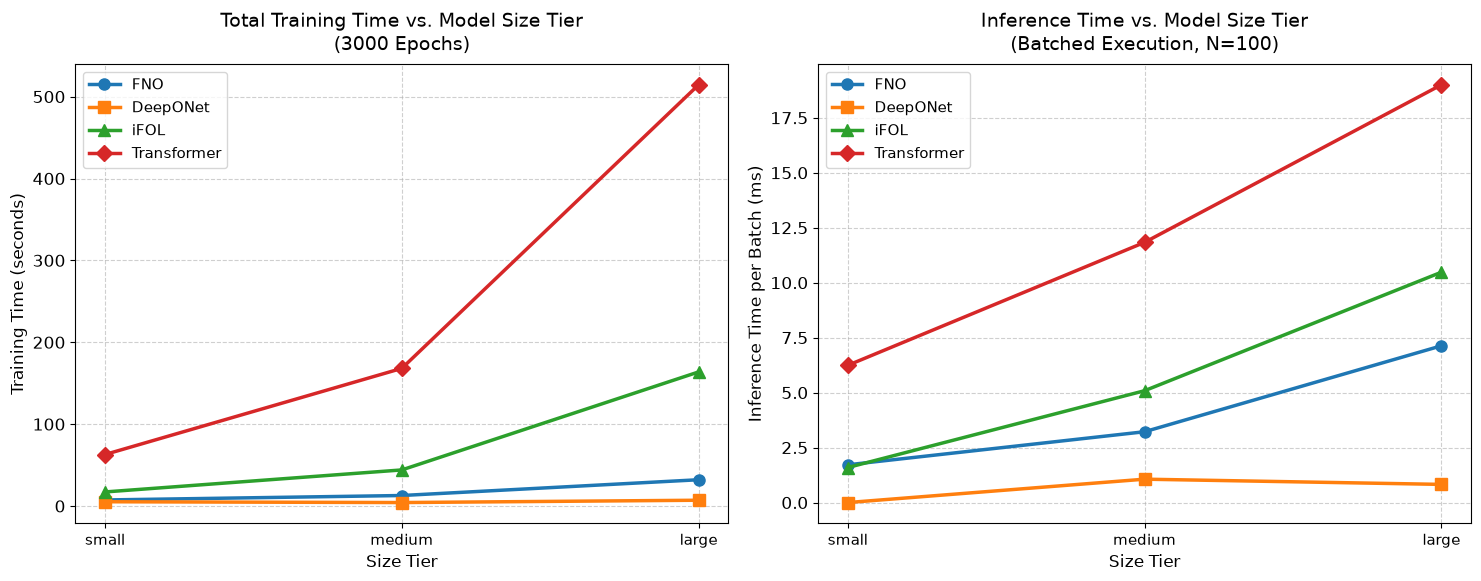

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import time
import jax

# ==========================================
# 1. GATHER TRAINING TIMES
# ==========================================
# Extracting the recorded training times from the main loop
train_times = {name: [results[size][name]['train_time'] for size in size_order] for name in model_order}

# ==========================================
# 2. BENCHMARK INFERENCE TIMES
# ==========================================
inference_times = {name: [] for name in model_order}
n_infer_runs = 20  # Number of forward passes to average over

print(f"Benchmarking inference times over {n_infer_runs} runs per model (batch size = {k_val_elem.shape[0]})...")

for name in model_order:
    for size in size_order:
        cfg = results[size][name]['cfg']
        params = results[size][name]['params_obj']
        _, predict_fn = FACTORIES[name](**cfg)
        
        # Wrap the prediction function in JIT and VMAP based on the model's signature
        if name == "Transformer":
            @jax.jit
            def pred_batch(p):
                return jax.vmap(lambda p_, k, x: predict_fn(p_, k, GRID, x), in_axes=(None, 0, 0))(p, k_val_elem, X_val_norm)
        else:
            @jax.jit
            def pred_batch(p):
                return jax.vmap(lambda p_, k: predict_fn(p_, k, GRID), in_axes=(None, 0))(p, k_val_elem)
        
        # Warmup pass to trigger JIT compilation
        _ = pred_batch(params).block_until_ready()
        
        # Timed benchmark loop
        t0 = time.time()
        for _ in range(n_infer_runs):
            _ = pred_batch(params).block_until_ready()
        t_end = time.time()
        
        # Calculate average time per batched execution in milliseconds
        avg_time_ms = ((t_end - t0) / n_infer_runs) * 1000
        inference_times[name].append(avg_time_ms)

# ==========================================
# 3. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
x_positions = np.arange(len(size_order))
markers = ['o', 's', '^', 'D']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# --- Plot 1: Training Time ---
for i, name in enumerate(model_order):
    ax1.plot(x_positions, train_times[name], marker=markers[i], color=colors[i], 
             label=name, linewidth=2.5, markersize=8)

ax1.set_title(f"Total Training Time vs. Model Size Tier\n({EPOCHS} Epochs)", fontsize=14, pad=10)
ax1.set_ylabel("Training Time (seconds)", fontsize=12)
ax1.set_xlabel("Size Tier", fontsize=12)
ax1.set_xticks(x_positions)
ax1.set_xticklabels(size_order, fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=11)

# --- Plot 2: Inference Time ---
for i, name in enumerate(model_order):
    ax2.plot(x_positions, inference_times[name], marker=markers[i], color=colors[i], 
             label=name, linewidth=2.5, markersize=8)

ax2.set_title(f"Inference Time vs. Model Size Tier\n(Batched Execution, N={k_val_elem.shape[0]})", fontsize=14, pad=10)
ax2.set_ylabel("Inference Time per Batch (ms)", fontsize=12)
ax2.set_xlabel("Size Tier", fontsize=12)
ax2.set_xticks(x_positions)
ax2.set_xticklabels(size_order, fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

## 13. Conclusion: which architecture we carry forward

The three questions give different winners, and the choice follows from weighing them:

- **In-distribution accuracy** is not where the FNO leads. iFOL is clearly the most accurate at the small and medium tiers, and at the large tier the Transformer is best, with iFOL and FNO close behind. DeepONet overtakes the FNO at the medium tier too.
- **Out-of-distribution generalization** — unseen material shapes on grids up to four times finer — is where the FNO is strongest among the affordable models. At every tier it beats both DeepONet and iFOL, and its OOD error keeps falling as capacity grows, whereas iFOL's does not improve with size. Only the Transformer matches it, marginally.
- **Cost.** The FNO trains in seconds to tens of seconds. The Transformer costs roughly 8–16× more at every tier, and iFOL's cost grows steeply with size.

We therefore carry the **FNO** forward into the transient study. It generalizes best out of distribution at a small fraction of the Transformer's cost, and generalization is what an operator reused on new materials and grids is for. The **Transformer** reaches similar or slightly better accuracy but is **excluded from the downstream pipeline on runtime grounds** (a dedicated transient Transformer is left as future work). iFOL's in-distribution accuracy makes it a strong alternative when test conditions match training, but its weaker out-of-distribution behaviour argues against it here.

With the loss (weighted residual) and the architecture (FNO) fixed, Part III moves to the transient problem, starting with [Data-Driven Operator Learning for Transient Nonlinear Heat Conduction](FNO_transient_data_driven.ipynb).